$\rule{800pt}{20pt}$

# Imports

In [ ]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import os

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
os.getcwd()

'/content'

In [ ]:
tf.test.gpu_device_name()

''

In [ ]:
images_path = '/content/drive/My Drive/DSO_464_Spring_2024/Images/'

data_path = '/content/drive/My Drive/DSO_464_Spring_2024/14_Neural_Networks_for_Sequence_Data_Attention_Mechanism_and_Transformers_NNs_I_EX_Autoregressive_LLMs_and_GPTs/Data/'

$\rule{800pt}{20pt}$

$\rule{800pt}{20pt}$

# GPT = Generative Pretrained Transformer

- What is generative?

- What is pretrained?

- What is a transformer?

- This is what we will attempt to answer in this module.

$\rule{800pt}{20pt}$

# The Wave of Generative AI

- By now I hope we have an idea about AI, but what is <b>generative</b> about AI, and how does that compare with non-generative AI?

- Let's first start by trying to discuss how GenAI has been described (from a sensible source).

  - GenAI is a type of artificial intelligence that can create new content such as text, images, music, audio, and videos.
  
  - It does this by learning patterns from existing data, then using this knowledge to generate new and unique outputs.

  - Generative AI is capable of producing highly realistic and complex content that mimics human creativity.

  - Recent advancements in the field have significantly advanced the capabilities of generative AI.

  - Generative AI is not sentient or conscious. It is a machine learning algorithm that is trained on data to generate new content.

  - Generative AI is not magic. It cannot create anything that is not already possible in the real world.

  - Generative AI is not perfect, it can sometimes make mistakes.


---

---

---

  - From a user's perspective, GenAI functions by receiving a prompt (input data), generating data, and then showing an output; examples include:
  
    - Google's Bard, now Gemini,
    
    - OpenAI's ChatGPT,

    - Anthropic's Claude,
    
    - or Meta's LLaMa 3 (open-source).
    
    - This input can be text, audio, image, video, or a mix of these (multi-modal data).

---

---

---    

  - GenAI does NOT only refer to large-language models; it can refer to:
  
    - Variational Auto-Encoders (VAEs)

    - Generative Adversarial Networks (GANs)

    - Autoregressive Models (ARs)

    - Diffusion Models

    - etc.

---

---

---    
  
  - GenAI can be trained on specialized datasets, such as:
  
    - geospatial data,
    
    - genomic data,
    
    - or protein structures!



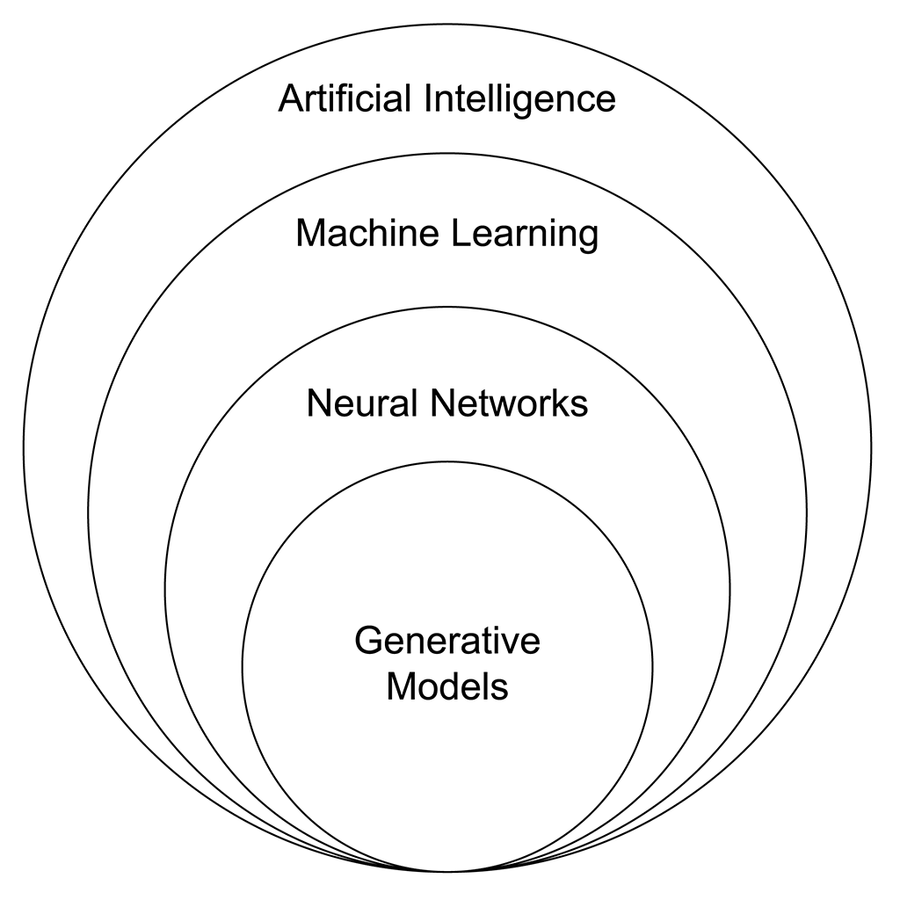

In [ ]:
tf.keras.preprocessing.image.load_img(os.path.join(images_path, 'AI_relation_to_Generative_Models_Venn_Diagram.png'))

- Generative AI is a subset of deep learning, however:

  - deep learning is often used for <b>discriminative</b> tasks, like classifying images or predicting outcomes based on a set of inputs.


- The underlying technical architecture of standard deep learning is different from generative model architectures.

- Deep learning tends to find specific answers, while generative models produces <i>new</i> data.

- This is difficult to evaluate, so we have to be careful with how we think about how measuring success of our generations.

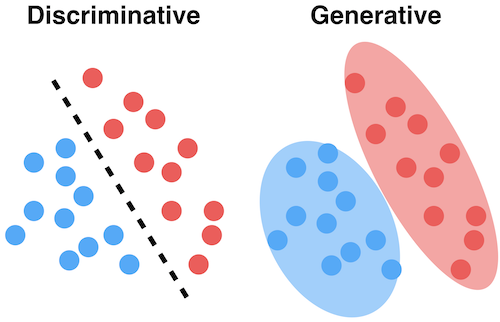

In [ ]:
tf.keras.preprocessing.image.load_img(os.path.join(images_path, 'discriminitive_vs_generative_1.png'))

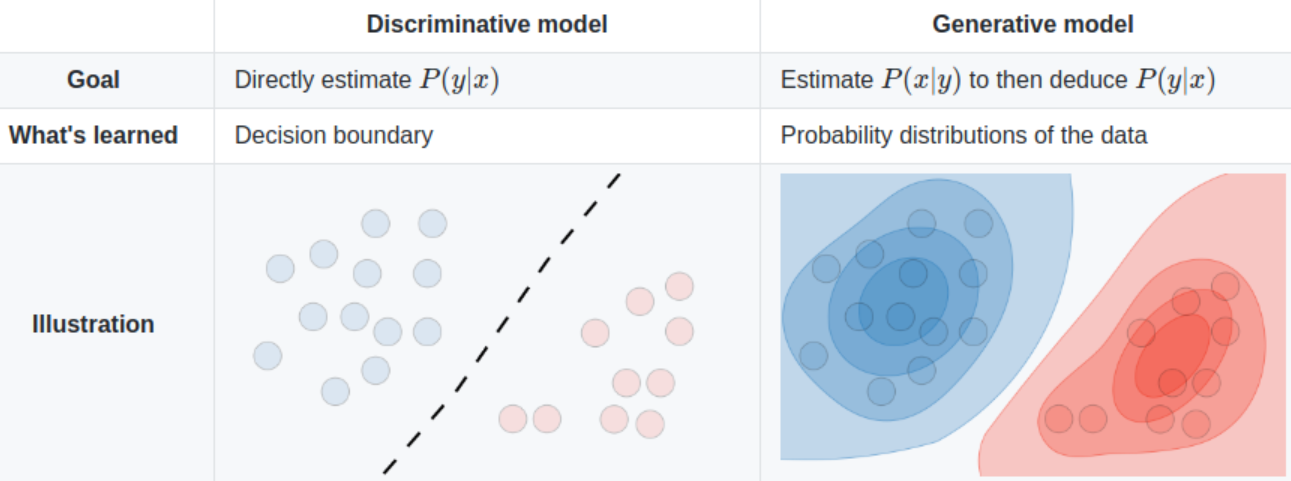

In [ ]:
tf.keras.preprocessing.image.load_img(os.path.join(images_path, 'discriminitive_vs_generative_2.png'))

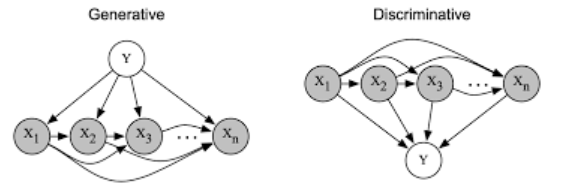

In [ ]:
tf.keras.preprocessing.image.load_img(os.path.join(images_path, 'discriminitive_vs_generative_3.png'))

## Discriminitive Modeling vs Generative Modeling

- Up until now, we have primarily focused on <b>discriminative</b> modeling techniques with deep learning models.

  - This typically refers to either directly or indirectly modeling the conditional probabilities of the target variable given the data: $$\mathbb{P}(Y \ | \mathbf{X}).$$

- We are now exploring <b>generative</b> modeling techniques with deep learning models.

  - This typically refers to either directly or indirectly modeling probabilities of the data: $$\mathbb{P}(\mathbf{X}),$$ or the conditional probabilities of the data given the target: $$\mathbb{P}(\mathbf{X} \ | Y).$$

  - This model of the data $\mathbb{P}(\mathbf{X})$ gives us a distribution we can sample from.

- These are related through <a href="https://en.wikipedia.org/wiki/Bayes%27_theorem">Bayes theorem</a> $$\mathbb{P}(Y \ | \mathbf{X}) = \frac{\mathbb{P}(\mathbf{X}, Y)}{\mathbb{P}(\mathbf{X})} = \frac{\mathbb{P}(\mathbf{X} \ | Y) \ \mathbb{P}(Y)}{\mathbb{P}(\mathbf{X})}.$$

- Generative modeling can help when there is a lack of labeled data, which refers to <i>semi-supervised</i> and <i>self-supervised</i> learning.

- These formulas also benefit from the <a href="https://en.wikipedia.org/wiki/Law_of_total_probability">law of total probability</a>: $$\mathbb{P}(\mathbf{X}) = \int \underbrace{\mathbb{P}(\mathbf{X} \ | \mathbf{h})}_{\text{model data as}\\ \text{ function of } \\ \text{latent variables}} \mathbb{P}(\mathbf{h}) d\mathbf{h},$$ which can allow for modeling of the data as a function of (low-dimensional) latent variables $\mathbb{h}$.

  - This can allow us to label data that is otherwise unlabeled.

- Generative models can fall into a few different categories:

  - <a href="https://lilianweng.github.io/posts/2018-08-12-vae/">VAEs</a>: approximate inference by first using a posterior distribution encoder and a likelihood function decoder; these models use the posterior distribution encoder to generate output $q_{\phi}(z|x)$.
  
  - GANs: optimize generative model by fooling classifier

  - Flow-based models:  transform latent distribution by a series of invertible functions

  - <a href="https://lilianweng.github.io/posts/2021-07-11-diffusion-models/">Diffusion models</a>: gradually add Gaussian noise to the data, and then reverse

  - <a href="https://lilianweng.github.io/posts/2019-01-31-lm/">Autoregressive models</a>: sequentially generate next term given the history $$p(\mathbf{x})=p(x_1)p(x_2|x_1)p(x_3|x_2,x_1) \dots $$

---
---
---

- For more, see <a href="https://cedar.buffalo.edu/~srihari/CSE574/Chap1/Discriminative-Generative.pdf">here</a> or <a href="https://cedar.buffalo.edu/~srihari/CSE574/Discriminative-Generative.pdf">here</a> or <a href="https://cedar.buffalo.edu/~srihari/talks/IISc-DL4">here for generative models in deep learning</a>.

- <a href="https://www.microsoft.com/en-us/research/blog/a-deep-generative-model-trifecta-three-advances-that-work-towards-harnessing-large-scale-power/">
A deep generative model trifecta: Three advances that work towards harnessing large-scale power (Microsoft)</a>

- <a href="https://openai.com/research/generative-models">Research: Generative models (OpenAI 2016)</a>

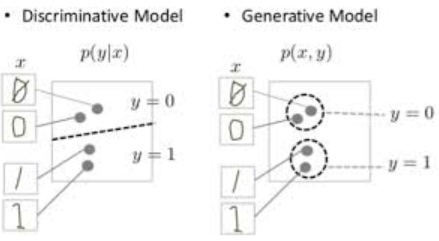

In [ ]:
tf.keras.preprocessing.image.load_img(os.path.join(images_path, 'discriminitive_vs_generative_4.png'))

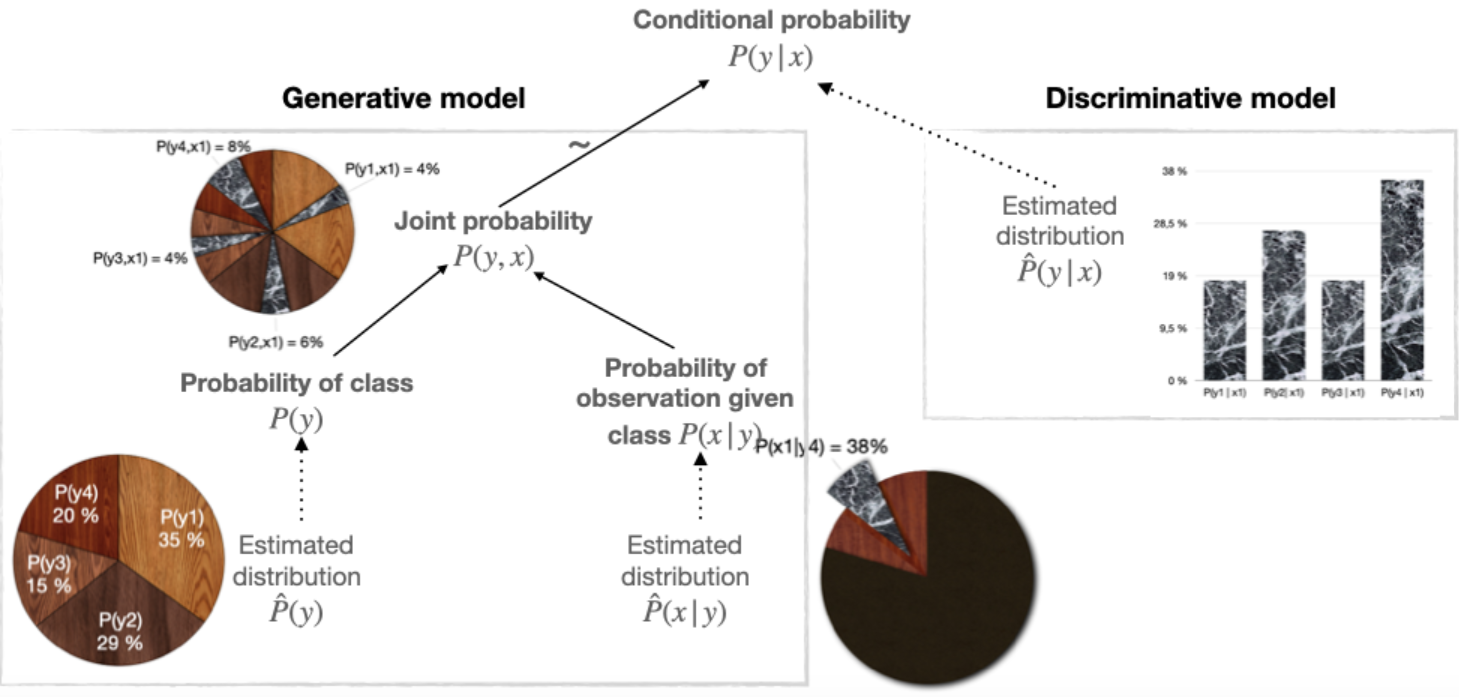

In [ ]:
tf.keras.preprocessing.image.load_img(os.path.join(images_path, 'discriminitive_vs_generative_5.png'))

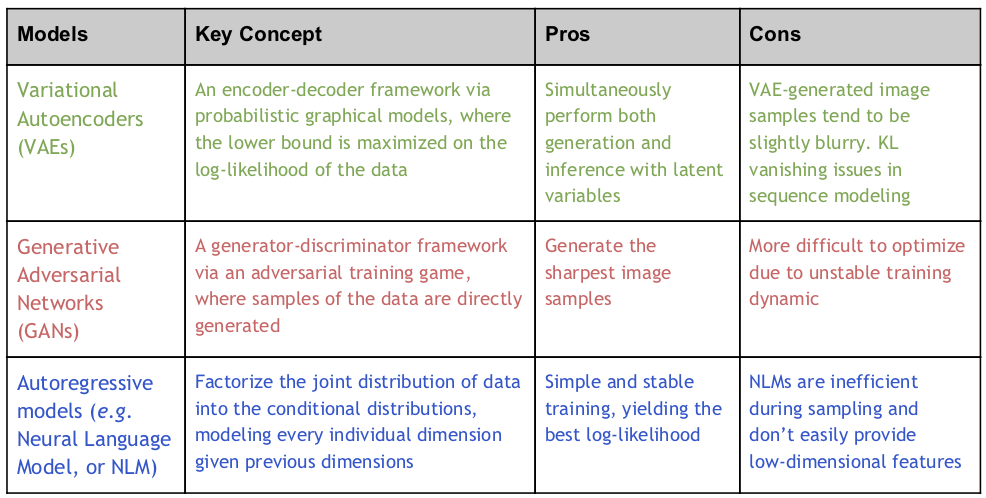

In [ ]:
tf.keras.preprocessing.image.load_img(os.path.join(images_path, 'taxonomy_of_some_generative_models.png'))

## Economics of Large-Scale Models and Pre-trained Models

- It is important for executives steering a company to consider costs when building their GenAI strategies.

- Many executives are facing a crisis of costs from a previous digital innovation: cloud migration projects and cloud computing costs for those with existing cloud infrastructure.

  - Many who have succefully migrated to the cloud are considering retreating from the cloud due to the pressures of unforeseen costs.
  
  - This exodus highlights a critical issue: <b>the insufficient consideration of full lifecycle costs during the strategic planning phase</b>.
  
---
---
---
  
- Generative AI is a technology that requires a holistic approach that includes intricate system design and an understanding of the nuanced hidden costs.

- These costs include:

  - <b>inference costs</b>, i.e. calling <i>.predict(data)</i> incurs the utilization of compute resources

    - For example, the inference cost of generating a text completion from a LLM such as GPT-4 is typically around $0.006$ per 1,000 output tokens plus $0.003$ per 1,000 input tokens.
    
    - Tokens are groups of words, where 1,000 tokens are roughly 750 words.
    
    - The inference cost of generating an image from a large image generation model such as DALL-E 2 is typically around $0.18 per image.

    - These inference costs can be a large hurdle for adoption by companies, especially if they need to generate large volumes of content.

    - You could reduce inference costs by using a smaller model, hosting an open-source LLM, optimizing the inference process, etc.

  - <b>fine-tuning costs</b>, i.e. adapting a pre-trained model for a specific task or domain, which involves some amount of training on new data

    - to estimate the costs for a specific fine-tuning job, <a href="https://platform.openai.com/docs/guides/fine-tuning/estimate-costs">according to OpenAI</a>, use the formula: $1k$ tokens $\times$ number of tokens in the training file $\times$ number of epochs trained

    - For a training file with 100,000 tokens trained over 3 epochs, the expected cost would be ~$2.40 USD.

    - One could use some tricks for reducing training costs such as <i>transfer learning</i> and <i>distributed training</i>.

  - <b>prompt engineering costs</b>, the cost of structuring text in a way that can be interpreted and understood by a model

    - there's a natural balance between prompt engineering and fine-tuning

    - if the task requires a high degree of accuracy and precision, then fine-tuning will be best, despite it being more expensive and time-consuming; these decisions depend on the budget and resources of the executives, as well as the available expertise within the company.

  - <b>cloud costs</b>, which requires a holistic overall cloud architecture plan (that includes any business constraints) to estimate these costs, it isn't just the costs of hosting the model

  - <b>talent costs</b>, i.e. how to compete in the labor market while avoiding a short-term rush for talent, which could lead to large payroll costs

    - because these models could create entirely new job categories, it is important to have a HR plan in place

  - <b>operation costs</b>, i.e. cost of ML operations (MLOps), which refers to the at-scale performance of these models in production

- Potential hidden costs include:

  - infrastructure overhaul

  - data security

  - ethical considerations

  - etc.


---
---
---

- For more, see:
  
  - <a href="https://sunyan.substack.com/p/the-economics-of-large-language-models">The Economics of Large Language Models: The Cost of ChatGPT-like Search, Training GPT-3, and a General Framework for Mapping The LLM Cost Trajectory</a>

  - <details><summary><a href="https://www.wsj.com/articles/cfos-tackle-thorny-calculus-on-gen-ai-whats-the-return-on-investment-24ebf435">WSJ: CFOs Tackle Thorny Calculus on Gen AI: What's the Return on Investment?</a></summary>

    - <i>“In the spirit of the unknown, organizations are taking a leap of faith,” said Todd Lohr, U.S. technology consulting leader at KPMG, adding that companies are gauging returns using metrics such as productivity gains and employee satisfaction, as well as revenue. “This might not be the traditional ROI,” he said.</i>

    - <i>Companies can pay to use proprietary models from providers such as OpenAI, or fine-tune those models as needed. They can also build their own generative AI tools using open-source models, such as Meta's Llama 2 AI model. Few companies build their own large language models from scratch; for most, the costs involved in such an endeavor would make the math on AI completely out of the question....For companies that want to build tools on top of OpenAI's GPT models, the price varies based on the volume of content fed into and generated by the models. </i>

    - <i>Winkler, along with Motorola Chief Technology Officer Mahesh Saptharishi, this year developed a framework designed to evaluate benefits from the investments, for instance, by tracking the hours it takes to complete a task with a generative AI tool and without it.</i>

    - <i>Intuit, which owns financial software brands such as TurboTax, QuickBooks and Credit Karma, is using and testing generative AI across its product lines to help answer customer questions or generate invoice reminders. The company uses generative AI models from external providers, such as OpenAI and Anthropic, as well as large language models that it is building using open-source models and training them on its own proprietary data. Intuit declined to say how much the company is spending on generative AI. But one way it keeps the costs under control is by querying its own models, rather than by sending all of its queries to third parties, which costs money, said CFO Sandeep Aujla. Some of the AI-driven features Intuit has introduced for its customers are expected to provide the company with pricing power over time, Aujla said.</i>

    - <i>Software company Autodesk is also looking for possible uses of generative AI within the finance team itself. It is already applying the technology to help with forecasting and identifying patterns in customers’ consumption of cloud services, which allows Autodesk to predict its own future cloud costs, CFO Debbie Clifford said.
    
      Clifford said she could imagine also using generative AI for financial reporting and is watching closely to see how SAP, Autodesk’s provider of software that connects the key parts of its operations, puts generative AI to work in their applications, she said.

      The finance department’s generative AI budget is “small” compared with the company’s overall AI budget, according to Clifford. But as AI is more widely used across the finance team the department’s hiring costs may change, she said.

     “If we're able to automate some of the processes that underpin the ability for those more strategic finance people to be successful, we might be hiring fewer people on an incremental basis in the long-term,” she said.</i></details

  - <a href="https://www2.deloitte.com/us/en/insights/industry/technology/technology-media-and-telecom-predictions/2024/generative-ai-enterprise-software-revenue-prediction.html">Deloitte: Generative AI and enterprise software: What's the revenue uplift potential?</a>

  - <a href="https://hbr.org/2023/11/what-ceos-need-to-know-about-the-costs-of-adopting-genai">HBR: What CEOs Need to Know About the Costs of Adopting GenAI</a>

  - <a href="https://arxiv.org/pdf/2306.07402.pdf">The economic trade-offs of large language models: A case study (2023)</a>

$\square$  

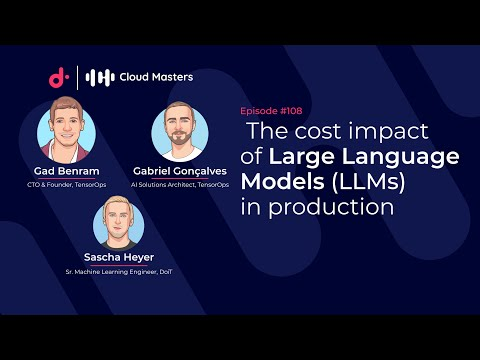

In [ ]:
from IPython.display import YouTubeVideo
# https://www.youtube.com/watch?v=gkGR4pYPqEQ
YouTubeVideo('gkGR4pYPqEQ', width=900, height=600)

$\rule{800pt}{20pt}$

# A Framework For How To Think About Business Analytics Problems

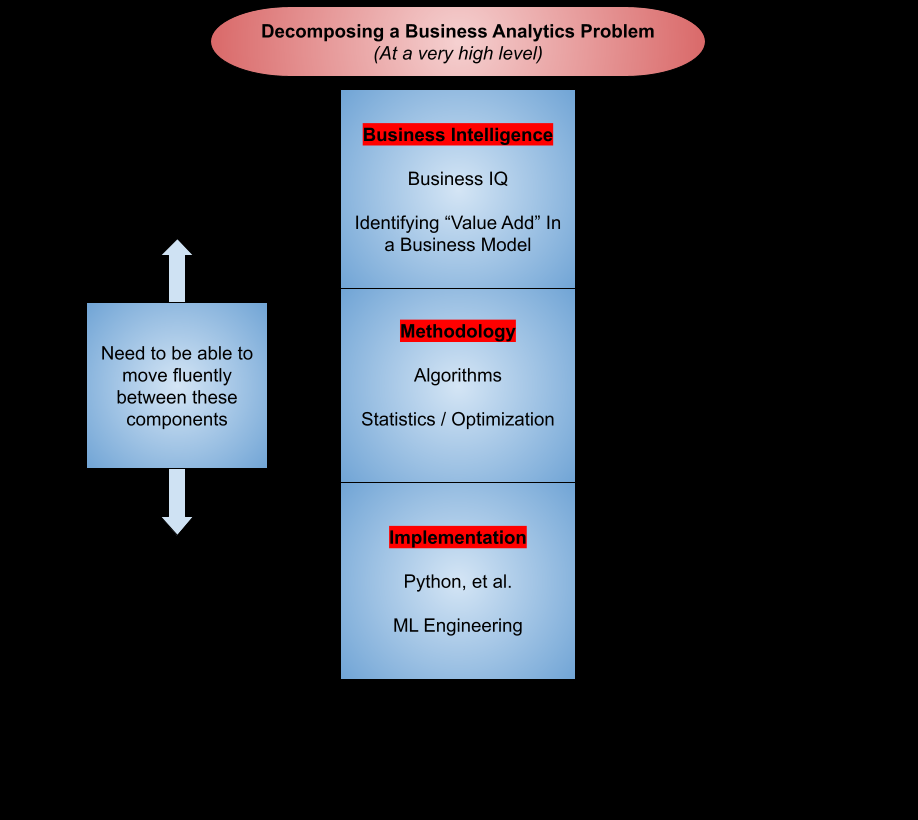

In [ ]:
tf.keras.preprocessing.image.load_img(os.path.join(images_path, 'Outline_for_Decomposing_Analytics_Problems.png'))

$\rule{800pt}{20pt}$

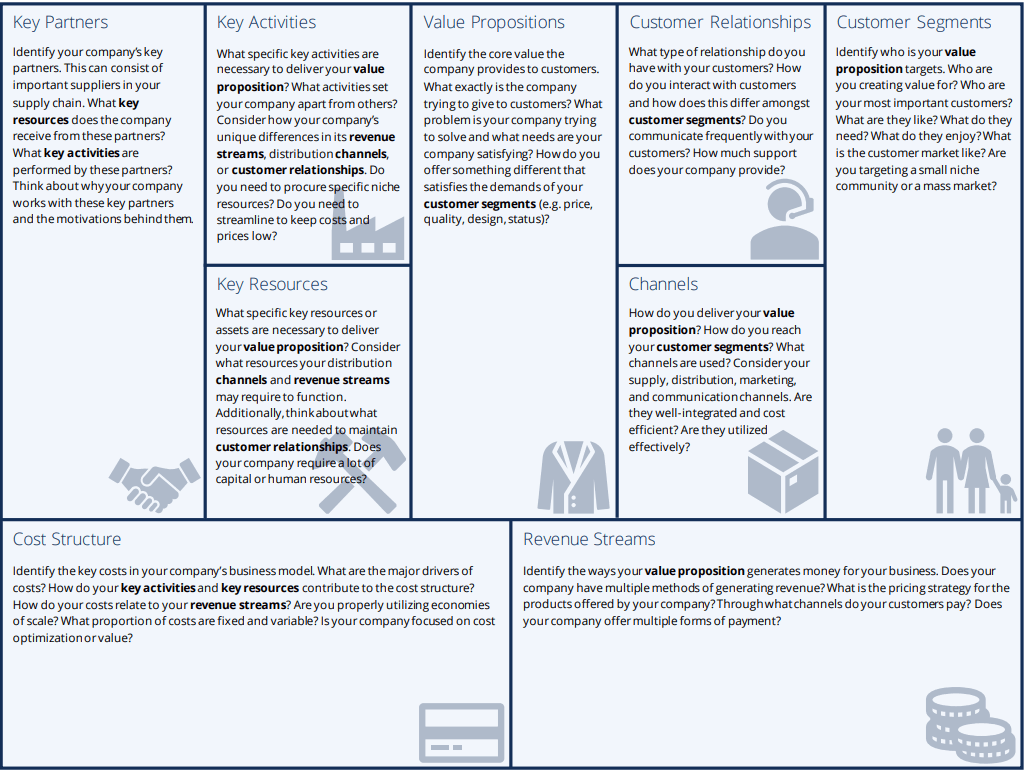

In [ ]:
tf.keras.preprocessing.image.load_img(os.path.join(images_path, 'Business_Model_Canvas_2.png'))

## How is Generative AI Impacting the Existing Business Models, and Creating New Business Models?
<br>
<font size="+1">
    <ul>
        <li><font color="blue">Whenver you are considering technology, you should always spend time considering how the technology could impact, i.e. add value to,  pieces of firm's <b>business model</b>.</li>
        <br>
       <li>It is not uncommon that this simply boils down to measuring impact on key performance indicators (KPIs).</font></li>
        <br>
        $\rule{800pt}{10pt}$
        <br>
        <br>
        <li>What do you think?</li>
        <br>
    </ul>
</font>

$\square$

$\rule{800pt}{20pt}$


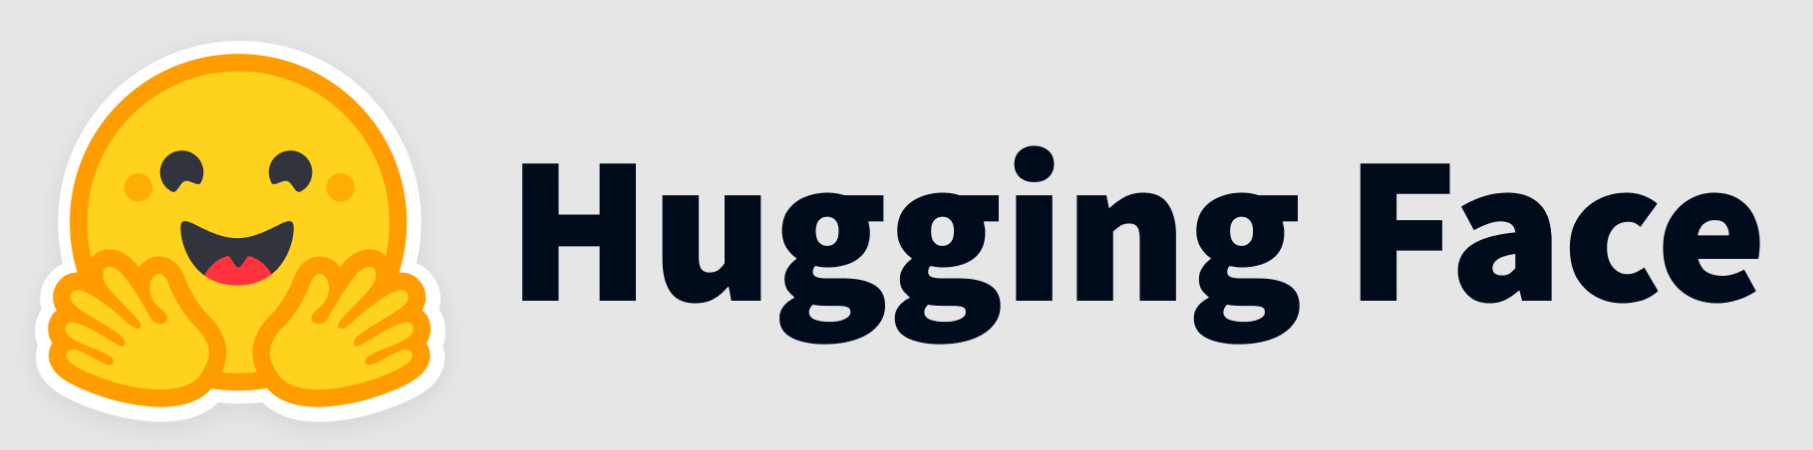

In [ ]:
tf.keras.preprocessing.image.load_img(os.path.join(images_path, 'hugging_face_1.png'))

# <a href="https://huggingface.co/">Hugging Face</a>
<br>
<font size="+1">
  <ul>
    <li>Hugging Face, Inc. is a French-American company founded in 2016 that was originally attempting to develop a chatbot targeted for teenagers (hence the hugging face emoji), and has since evolved into a platform that allows users to share ML models and datasets, as well as providing a rich suite of transformer-based models.</li>
    <br>
    <li>The business model pivot came after the company open-sourced the model behind the chatbot, and the company realized they are better suited for being a machine learning platform.</li>
    <br>
    <li>In 2022, the company announced the <b><a href="https://huggingface.co/enterprise">Private (Enterprise) Hub</a></b> that supports SaaS or on-premises deployment, and in 2023 they developed a partnership with AWS which would allow their products to be available to AWS customers.</li>
    <br>
    <li>A large technology they provide is their <a href="https://huggingface.co/docs/transformers/index">transformers library</a>, which is a Python package that contains open-source implementations of transformer models for text, image, and audio tasks.</li>
    <br>
    <ul>
      <li>This library is compatible with PyTorch, TensorFlow, and JAX deep learning libraries.</li>
      <br>
      <li>It includes notable implementations such as BERT and GPT-2 (the library was originally called "pytorch-pretrained-bert" -> "pytorch-transformers" -> "transformers"</li>
      <br>
    </ul>
    <li>A service they provide is their <a href="https://huggingface.co/docs/transformers/index">Hugging Face Hub</a>, which is a platform (centralized web service) for hosting:</li>
    <br>
    <ul>
      <li>Git-based code repos,</li>
      <br>
      <li>models, also with Git-based version control,</li>
      <br>
      <li>datasets, mainly in text, images, and audio,</li>
      <br>
      <li>web applications (spaces and widgets), intended for small-scale demos of ML applications</li>
      <br>
    </ul>
    <li>Check out their <a href="https://huggingface.co/pricing">pricing</a> to see how they are currently "monetizing" their platform.</li>
    <br>
    <li>For more, see</li>
    <br>
    <ul>
      <li><a href="https://en.wikipedia.org/wiki/Hugging_Face">Hugging Face Wiki</a></li>
      <br>
      <li><a href="https://huggingface.co/docs/transformers/index">Hugging Face's Transformers Library</a></li>
      <br>
      <li><a href="https://huggingface.co/docs/transformers/v4.39.3/en/main_classes/pipelines#transformers.pipeline">Hugging Face Pipeline</a> and <a href="https://huggingface.co/docs/transformers/en/task_summary">Hugging Face Transformers Tasks Summary</a></li>
      <br>
      <li>YC - Hacker News: Hugging Face raises $235M from investors including Salesforce and Nvidia (techcrunch.com)</li>
      <br>
</li>
    </ul>
  </ul>
</font>

$\square$

$\rule{800pt}{20pt}$

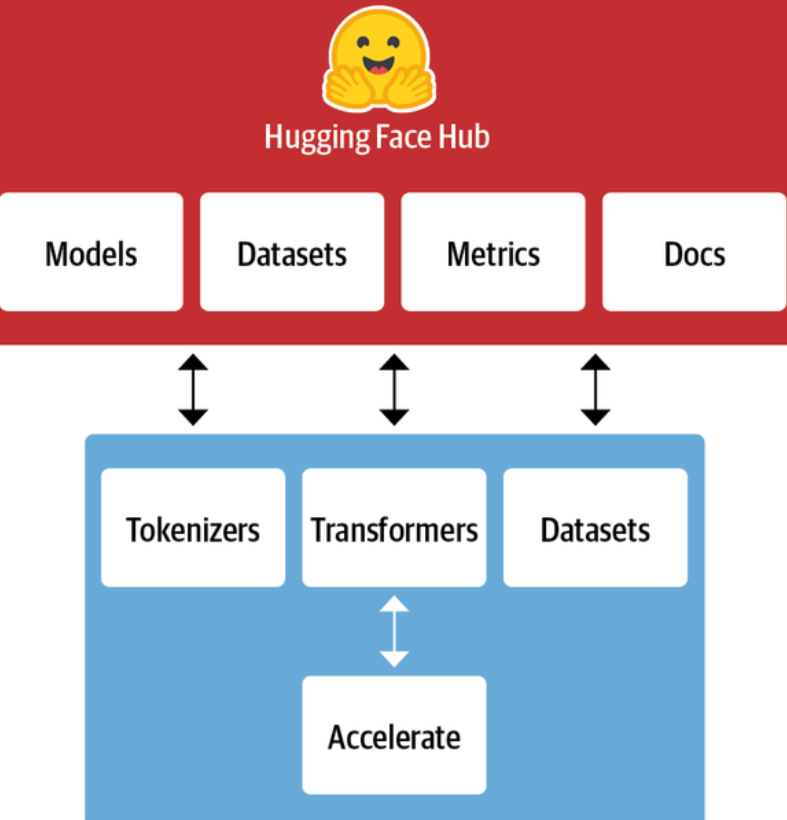

In [ ]:
tf.keras.preprocessing.image.load_img(os.path.join(images_path, 'hugging_face_2.png'))

$\rule{800pt}{20pt}$

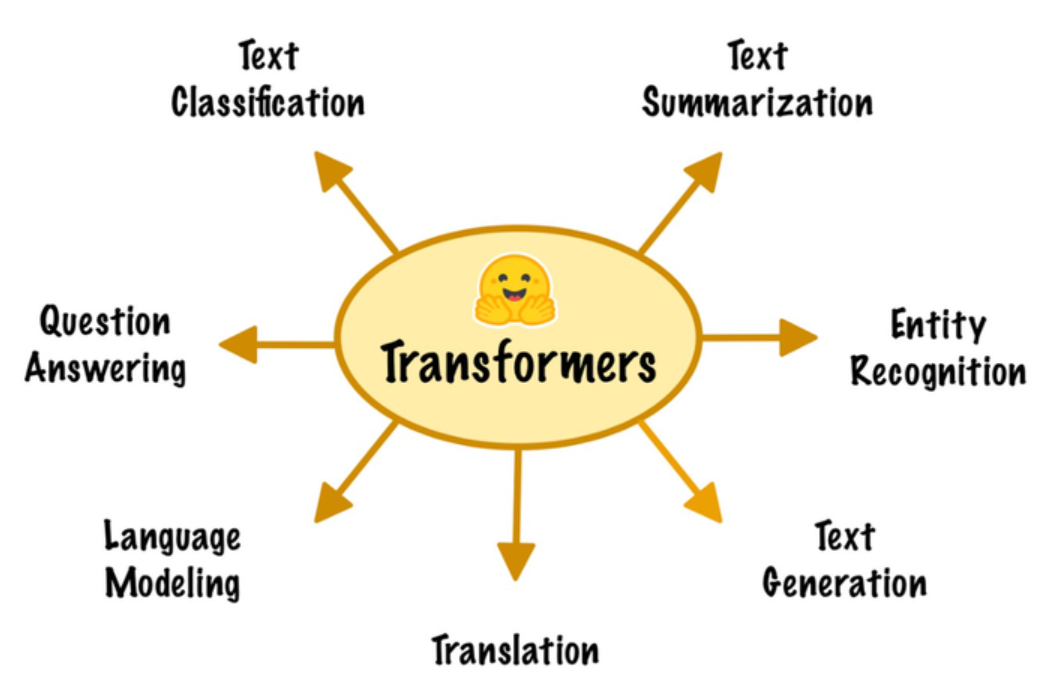

In [ ]:
tf.keras.preprocessing.image.load_img(os.path.join(images_path, 'hugging_face_3.png'))

$\rule{800pt}{20pt}$


## Inference with <a href="https://huggingface.co/docs/transformers/en/main_classes/pipelines">Hugging Face Pipeline</a>

- The pipelines are a great and easy way to use models for inference.

- These pipelines are objects that abstract most of the complex code from the library, offering a simple API dedicated to several tasks.

- There is a general <b>pipeline()</b> method which encapsulates all other pipelines, and there is a task-specific pipeline available for different specific tasks.

In [29]:
from transformers import pipeline

classifier = pipeline(task="sentiment-analysis")

classifier

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision af0f99b (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.


In [30]:
classifier("The actors were very convincing.")

[{'label': 'POSITIVE', 'score': 0.9998071789741516}]

In [ ]:
classifier("Today's atmosphere carries a hint of something, a subdued clash that subtly influences the mood down.")

[{'label': 'NEGATIVE', 'score': 0.5515621900558472}]

In [ ]:
type(classifier)

transformers.pipelines.text_classification.TextClassificationPipeline

In [ ]:
classifier(["I am from California.", "I am from Arkansas."])

[{'label': 'POSITIVE', 'score': 0.9862968921661377},
 {'label': 'POSITIVE', 'score': 0.7881162166595459}]

In [ ]:
classifier(["I am from California.", "I am from Mississippi."])

[{'label': 'POSITIVE', 'score': 0.9862968921661377},
 {'label': 'POSITIVE', 'score': 0.6966632604598999}]

In [ ]:
states = [
    "Alabama", "Alaska", "Arizona", "Arkansas", "California", "Colorado", "Connecticut", "Delaware", "Florida", "Georgia",
    "Hawaii", "Idaho", "Illinois", "Indiana", "Iowa", "Kansas", "Kentucky", "Louisiana", "Maine", "Maryland",
    "Massachusetts", "Michigan", "Minnesota", "Mississippi", "Missouri", "Montana", "Nebraska", "Nevada", "New Hampshire",
    "New Jersey", "New Mexico", "New York", "North Carolina", "North Dakota", "Ohio", "Oklahoma", "Oregon", "Pennsylvania",
    "Rhode Island", "South Carolina", "South Dakota", "Tennessee", "Texas", "Utah", "Vermont", "Virginia", "Washington",
    "West Virginia", "Wisconsin", "Wyoming"
]


In [ ]:
for state in states:
  print(state, classifier([f"I am from {state}."]))

Alabama [{'label': 'POSITIVE', 'score': 0.962405264377594}]
Alaska [{'label': 'POSITIVE', 'score': 0.9793797731399536}]
Arizona [{'label': 'POSITIVE', 'score': 0.9683094620704651}]
Arkansas [{'label': 'POSITIVE', 'score': 0.7881162166595459}]
California [{'label': 'POSITIVE', 'score': 0.9862968921661377}]
Colorado [{'label': 'POSITIVE', 'score': 0.9856982827186584}]
Connecticut [{'label': 'POSITIVE', 'score': 0.9577044248580933}]
Delaware [{'label': 'POSITIVE', 'score': 0.9256526827812195}]
Florida [{'label': 'POSITIVE', 'score': 0.9894739985466003}]
Georgia [{'label': 'POSITIVE', 'score': 0.9951040744781494}]
Hawaii [{'label': 'POSITIVE', 'score': 0.9900732040405273}]
Idaho [{'label': 'POSITIVE', 'score': 0.9726606011390686}]
Illinois [{'label': 'POSITIVE', 'score': 0.9798118472099304}]
Indiana [{'label': 'POSITIVE', 'score': 0.9865374565124512}]
Iowa [{'label': 'POSITIVE', 'score': 0.9817480444908142}]
Kansas [{'label': 'POSITIVE', 'score': 0.9718557596206665}]
Kentucky [{'label': 'P

In [ ]:
european_countries = [
    "Albania", "Andorra", "Austria", "Belarus", "Belgium", "Bosnia and Herzegovina", "Bulgaria", "Croatia", "Cyprus",
    "Czech Republic", "Denmark", "Estonia", "Finland", "France", "Germany", "Greece", "Hungary", "Iceland", "Ireland",
    "Italy", "Kosovo", "Latvia", "Liechtenstein", "Lithuania", "Luxembourg", "Malta", "Moldova", "Monaco", "Montenegro",
    "Netherlands", "North Macedonia", "Norway", "Poland", "Portugal", "Romania", "Russia", "San Marino", "Serbia",
    "Slovakia", "Slovenia", "Spain", "Sweden", "Switzerland", "Ukraine", "United Kingdom", "Vatican City"
]


In [ ]:
for c in european_countries:
  print(c, classifier([f"I am from {c}."]))

Albania [{'label': 'POSITIVE', 'score': 0.9946430921554565}]
Andorra [{'label': 'POSITIVE', 'score': 0.994479775428772}]
Austria [{'label': 'POSITIVE', 'score': 0.9811134338378906}]
Belarus [{'label': 'POSITIVE', 'score': 0.9889965057373047}]
Belgium [{'label': 'POSITIVE', 'score': 0.9948632121086121}]
Bosnia and Herzegovina [{'label': 'POSITIVE', 'score': 0.9885744452476501}]
Bulgaria [{'label': 'POSITIVE', 'score': 0.9917363524436951}]
Croatia [{'label': 'POSITIVE', 'score': 0.9831807017326355}]
Cyprus [{'label': 'POSITIVE', 'score': 0.9917619228363037}]
Czech Republic [{'label': 'POSITIVE', 'score': 0.9952057003974915}]
Denmark [{'label': 'POSITIVE', 'score': 0.9934347867965698}]
Estonia [{'label': 'POSITIVE', 'score': 0.9907094240188599}]
Finland [{'label': 'POSITIVE', 'score': 0.9928650856018066}]
France [{'label': 'POSITIVE', 'score': 0.9940063953399658}]
Germany [{'label': 'POSITIVE', 'score': 0.7846043109893799}]
Greece [{'label': 'POSITIVE', 'score': 0.9933144450187683}]
Hunga

In [ ]:
tech_job_categories = [
    'Software Development',
    'Data Science',
    'Artificial Intelligence',
    'Machine Learning',
    'Cloud Computing',
    'Cybersecurity',
    'Web Development',
    'Network Engineering',
    'Database Administration',
    'DevOps',
    'UI/UX Design',
    'Product Management',
    'IT Support',
    'Quality Assurance',
    'Project Management',
    'Business Analysis',
    'Technical Writing',
    'Systems Architecture',
    'Embedded Systems',
    'Game Development',
    'Robotics',
    'Blockchain Development',
    'AR/VR Development',
    'Big Data Engineering',
    'Bioinformatics',
    'Quantitative Analysis',
    'Geospatial Analysis',
    'IT Consulting',
    'Telecommunications',
    'Wireless Networking',
    'IT Sales',
    'IT Training and Education',
    'Tech Journalism',
    'Technology Policy and Regulation',
    'Technical Recruiting'
]


In [ ]:
for job in tech_job_categories:
  print(job, classifier(f"I work in {job}."))

Software Development [{'label': 'NEGATIVE', 'score': 0.6687654852867126}]
Data Science [{'label': 'POSITIVE', 'score': 0.9953712821006775}]
Artificial Intelligence [{'label': 'NEGATIVE', 'score': 0.962648868560791}]
Machine Learning [{'label': 'POSITIVE', 'score': 0.9889652729034424}]
Cloud Computing [{'label': 'NEGATIVE', 'score': 0.5285761952400208}]
Cybersecurity [{'label': 'POSITIVE', 'score': 0.9906119704246521}]
Web Development [{'label': 'POSITIVE', 'score': 0.5746759176254272}]
Network Engineering [{'label': 'POSITIVE', 'score': 0.6553353667259216}]
Database Administration [{'label': 'NEGATIVE', 'score': 0.9524767994880676}]
DevOps [{'label': 'NEGATIVE', 'score': 0.9989343285560608}]
UI/UX Design [{'label': 'POSITIVE', 'score': 0.7620764970779419}]
Product Management [{'label': 'NEGATIVE', 'score': 0.6637769937515259}]
IT Support [{'label': 'POSITIVE', 'score': 0.9991695880889893}]
Quality Assurance [{'label': 'POSITIVE', 'score': 0.9998001456260681}]
Project Management [{'labe

- We can see the output has some sort of bias towards Technical Recruiting, for example.

- It isn't clear why the model has a negative sentiment for some jobs, but we could think of this as an undesirable bias.

- In general, these biases tend to leak into the model through the data itself, i.e. there could have been lots of negative reviews about certain jobs in the training set.

- This bias was then likely amplified during the fine-tuning process since the model was forced to choose between two classes: positive or negative. If you added a "neutral" class, then there is a good chance some of these job biases might go away.

- The training data is not the only source of bias:

  - the model's architecture,

  - the type of loss or regularization used for training,

  - the optimizer,

  - etc., can all impact what the model ends up learning.

- A big area of research is to understand bias in AI and mitigating its negative effects.  

  - You should pause and
  think before you rush to deploy a model to production.
  
  - Ask yourself how the model could do harm, even indirectly.
  
  - For example, if the model's predictions are used to decide whether or not to give someone a loan, the process should be fair (this is also regulated).
  
  - So, make sure you evaluate the model's performance not just on average over the whole test set, but across various subsets as well.
  
    - For example, you may find that although the model works very well on average, its performance is abysmal for some categories of people.
    
    - You may also want to run counterfactual tests: for example, you may want to check that the model's predictions do not change when you simply switch someone's income category or race.

  - If the model works well on average, it's tempting to push it to production and move on to something else, especially if it's just one component of a much larger system.
  
  - But in general, if you don't fix such issues, no one else will, and your model may end up doing more harm than good.
  
  - The solution depends on the problem: it may require rebalancing the dataset, fine-tuning on a different dataset, switching to another pretrained model, tweaking the model's architecture or hyperparameters, etc.    

---
---
---

- Let's change the model and see what happens.

- The pipeline() method uses a default model for the given task.

  - For example, as of 2024, for text classification tasks, such as sentiment analysis, it defaults to <b>distilbert-base-uncased-finetuned-sst-2-english</b>, which is a DistilBERT model with an uncased (no capitals) tokenizer, trained on English Wikipedia and a corpus (collection) of English books, and fine-tuned on the <a href="https://paperswithcode.com/dataset/sst">Stanford Sentiment Treebank v2 (SST 2)</a> task.

  - We can manually specify a different model.

  - For example, we can use a DistilBERT model, fine-tuned on the <a href="https://paperswithcode.com/dataset/multinli">MultiNLI task (multi-genre natural language inference)</a>, which classifies two sentences into three classes: contradiction, neutral, or entailment (deduction).

- We can fine more models on <a href="https://huggingface.co/models">Hugging Face -> Models</a>, and more tasks on <a href="https://huggingface.co/tasks">Hugging Face -> Tasks</a>.

In [ ]:
from transformers import pipeline

model_name = "huggingface/distilbert-base-uncased-finetuned-mnli"

classifier_mnli = pipeline(task="text-classification", model=model_name)

classifier_mnli

config.json:   0%|          | 0.00/729 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/58.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [ ]:
classifier_mnli("The actors were very convincing.")

[{'label': 'entailment', 'score': 0.6794421672821045}]

In [ ]:
classifier_mnli("I am happy, I am sad.")

[{'label': 'contradiction', 'score': 0.9973785877227783}]

In [ ]:
classifier_mnli("neutral") # what will give me a score of neutral??

[{'label': 'entailment', 'score': 0.8479775190353394}]

In [ ]:
classifier_mnli("I am not happy, and I am not sad, I am simply neutral")

[{'label': 'contradiction', 'score': 0.7617976665496826}]

In [ ]:
type(classifier_mnli)

transformers.pipelines.text_classification.TextClassificationPipeline

In [ ]:
states = [
    "Alabama", "Alaska", "Arizona", "Arkansas", "California", "Colorado", "Connecticut", "Delaware", "Florida", "Georgia",
    "Hawaii", "Idaho", "Illinois", "Indiana", "Iowa", "Kansas", "Kentucky", "Louisiana", "Maine", "Maryland",
    "Massachusetts", "Michigan", "Minnesota", "Mississippi", "Missouri", "Montana", "Nebraska", "Nevada", "New Hampshire",
    "New Jersey", "New Mexico", "New York", "North Carolina", "North Dakota", "Ohio", "Oklahoma", "Oregon", "Pennsylvania",
    "Rhode Island", "South Carolina", "South Dakota", "Tennessee", "Texas", "Utah", "Vermont", "Virginia", "Washington",
    "West Virginia", "Wisconsin", "Wyoming"
]


In [ ]:
for state in states:
  print(state, classifier_mnli([f"I am from {state}."]))

Alabama [{'label': 'entailment', 'score': 0.6318843960762024}]
Alaska [{'label': 'contradiction', 'score': 0.6384137868881226}]
Arizona [{'label': 'neutral', 'score': 0.6461026072502136}]
Arkansas [{'label': 'neutral', 'score': 0.4905707538127899}]
California [{'label': 'entailment', 'score': 0.4009639620780945}]
Colorado [{'label': 'entailment', 'score': 0.6129119396209717}]
Connecticut [{'label': 'entailment', 'score': 0.6521638035774231}]
Delaware [{'label': 'entailment', 'score': 0.6466916799545288}]
Florida [{'label': 'entailment', 'score': 0.5777250528335571}]
Georgia [{'label': 'neutral', 'score': 0.5339592695236206}]
Hawaii [{'label': 'neutral', 'score': 0.5643776655197144}]
Idaho [{'label': 'neutral', 'score': 0.7687520980834961}]
Illinois [{'label': 'entailment', 'score': 0.41003862023353577}]
Indiana [{'label': 'entailment', 'score': 0.6567335724830627}]
Iowa [{'label': 'entailment', 'score': 0.5159562826156616}]
Kansas [{'label': 'contradiction', 'score': 0.8290941715240479

In [ ]:
european_countries = [
    "Albania", "Andorra", "Austria", "Belarus", "Belgium", "Bosnia and Herzegovina", "Bulgaria", "Croatia", "Cyprus",
    "Czech Republic", "Denmark", "Estonia", "Finland", "France", "Germany", "Greece", "Hungary", "Iceland", "Ireland",
    "Italy", "Kosovo", "Latvia", "Liechtenstein", "Lithuania", "Luxembourg", "Malta", "Moldova", "Monaco", "Montenegro",
    "Netherlands", "North Macedonia", "Norway", "Poland", "Portugal", "Romania", "Russia", "San Marino", "Serbia",
    "Slovakia", "Slovenia", "Spain", "Sweden", "Switzerland", "Ukraine", "United Kingdom", "Vatican City"
]


In [ ]:
for c in european_countries:
  print(c, classifier_mnli([f"I am from {c}."]))

Albania [{'label': 'neutral', 'score': 0.5406728982925415}]
Andorra [{'label': 'entailment', 'score': 0.707638144493103}]
Austria [{'label': 'neutral', 'score': 0.44444939494132996}]
Belarus [{'label': 'entailment', 'score': 0.5811851024627686}]
Belgium [{'label': 'entailment', 'score': 0.6024236679077148}]
Bosnia and Herzegovina [{'label': 'entailment', 'score': 0.7581480145454407}]
Bulgaria [{'label': 'neutral', 'score': 0.7130954265594482}]
Croatia [{'label': 'neutral', 'score': 0.5056894421577454}]
Cyprus [{'label': 'entailment', 'score': 0.6323007345199585}]
Czech Republic [{'label': 'entailment', 'score': 0.7490620017051697}]
Denmark [{'label': 'entailment', 'score': 0.446920245885849}]
Estonia [{'label': 'neutral', 'score': 0.5794432759284973}]
Finland [{'label': 'neutral', 'score': 0.5367144346237183}]
France [{'label': 'entailment', 'score': 0.6208034753799438}]
Germany [{'label': 'contradiction', 'score': 0.6138611435890198}]
Greece [{'label': 'entailment', 'score': 0.5622532

In [ ]:
tech_job_categories = [
    'Software Development',
    'Data Science',
    'Artificial Intelligence',
    'Machine Learning',
    'Cloud Computing',
    'Cybersecurity',
    'Web Development',
    'Network Engineering',
    'Database Administration',
    'DevOps',
    'UI/UX Design',
    'Product Management',
    'IT Support',
    'Quality Assurance',
    'Project Management',
    'Business Analysis',
    'Technical Writing',
    'Systems Architecture',
    'Embedded Systems',
    'Game Development',
    'Robotics',
    'Blockchain Development',
    'AR/VR Development',
    'Big Data Engineering',
    'Bioinformatics',
    'Quantitative Analysis',
    'Geospatial Analysis',
    'IT Consulting',
    'Telecommunications',
    'Wireless Networking',
    'IT Sales',
    'IT Training and Education',
    'Tech Journalism',
    'Technology Policy and Regulation',
    'Technical Recruiting'
]


In [ ]:
for job in tech_job_categories:
  print(job, classifier_mnli(f"I work in {job}."))

Software Development [{'label': 'neutral', 'score': 0.6052946448326111}]
Data Science [{'label': 'neutral', 'score': 0.508962869644165}]
Artificial Intelligence [{'label': 'entailment', 'score': 0.5577788352966309}]
Machine Learning [{'label': 'contradiction', 'score': 0.8833010196685791}]
Cloud Computing [{'label': 'neutral', 'score': 0.5174472332000732}]
Cybersecurity [{'label': 'entailment', 'score': 0.5702820420265198}]
Web Development [{'label': 'neutral', 'score': 0.6531270146369934}]
Network Engineering [{'label': 'entailment', 'score': 0.44898444414138794}]
Database Administration [{'label': 'neutral', 'score': 0.5246751308441162}]
DevOps [{'label': 'contradiction', 'score': 0.5779926776885986}]
UI/UX Design [{'label': 'contradiction', 'score': 0.44404909014701843}]
Product Management [{'label': 'contradiction', 'score': 0.5239112973213196}]
IT Support [{'label': 'entailment', 'score': 0.8557743430137634}]
Quality Assurance [{'label': 'entailment', 'score': 0.6716336011886597}]

## Inference with a Specific Pipeline

- While the pipeline API is nice, sometimes you might need more control.

- For such cases, the Transformers library provides many classes that include

  - tokenizers,

  - models,

  - configurations,

  - callbacks,

  - etc.

- As an example, we will load the same DistilBERT model, with its tokenizer, and use the TFAutoModelForSequenceClassification and AutoTokenizer classes.

In [ ]:
model_name

'huggingface/distilbert-base-uncased-finetuned-mnli'

In [ ]:
import transformers

# pre-processing
tokenizer = transformers.AutoTokenizer.from_pretrained(model_name)

# processing
model = transformers.TFAutoModelForSequenceClassification.from_pretrained(model_name)

All PyTorch model weights were used when initializing TFDistilBertForSequenceClassification.

All the weights of TFDistilBertForSequenceClassification were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFDistilBertForSequenceClassification for predictions without further training.


- Now, let's tokenize a few sentences.

- We will specify that we want to <a href="https://huggingface.co/docs/transformers/en/pad_truncation">add padding</a> (i.e. extend sentences to all be of the same length) and TF tensors and not Python lists.

In [ ]:
token_ids = tokenizer(['I like soccer. [SEP] We all love soccer!',
                       'Joe lived for a very long time. [SEP] Joe is old.'],
                      padding=True, return_tensors='tf')

token_ids

{'input_ids': <tf.Tensor: shape=(2, 15), dtype=int32, numpy=
array([[ 101, 1045, 2066, 4715, 1012,  102, 2057, 2035, 2293, 4715,  999,
         102,    0,    0,    0],
       [ 101, 3533, 2973, 2005, 1037, 2200, 2146, 2051, 1012,  102, 3533,
        2003, 2214, 1012,  102]], dtype=int32)>, 'attention_mask': <tf.Tensor: shape=(2, 15), dtype=int32, numpy=
array([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]], dtype=int32)>}

- The output contains the sequence of token IDs, as well as a mask containing 0s for the padding tokens.

- Instead of passing "Sentence 1 [SEP] Sentence 2" to the tokenizer, you can equivalently
pass it a tuple: ("Sentence 1", "Sentence 2").

In [ ]:
token_ids_ = tokenizer(['I like soccer.',
                       'We all love soccer!'],
                      padding=True, return_tensors='tf')

token_ids_

{'input_ids': <tf.Tensor: shape=(2, 7), dtype=int32, numpy=
array([[ 101, 1045, 2066, 4715, 1012,  102,    0],
       [ 101, 2057, 2035, 2293, 4715,  999,  102]], dtype=int32)>, 'attention_mask': <tf.Tensor: shape=(2, 7), dtype=int32, numpy=
array([[1, 1, 1, 1, 1, 1, 0],
       [1, 1, 1, 1, 1, 1, 1]], dtype=int32)>}

- We can next directly pass this BatchEncoding object to the model.

- The model returns a classifier output object that contains the logit of the predicted classes, and we need to apply the softmax activation to convert these logits to class probabilities by applying the softmax activation function.

- Finally, use the argmax() function to predict the class with the highest probability of each input sentence pair.

In [ ]:
outputs = model(token_ids)

outputs

TFSequenceClassifierOutput(loss=None, logits=<tf.Tensor: shape=(2, 3), dtype=float32, numpy=
array([[-2.112382  ,  1.178679  ,  1.4101013 ],
       [-0.01478196,  1.0962462 , -0.99199617]], dtype=float32)>, hidden_states=None, attentions=None)

In [ ]:
Y_probabilities = tf.keras.activations.softmax(outputs.logits)

Y_probabilities

<tf.Tensor: shape=(2, 3), dtype=float32, numpy=
array([[0.01619701, 0.43523568, 0.5485673 ],
       [0.2265602 , 0.68817204, 0.08526775]], dtype=float32)>

In [ ]:
Y_hat = tf.argmax(Y_probabilities, axis=1)

Y_hat

<tf.Tensor: shape=(2,), dtype=int64, numpy=array([2, 1])>

- Note that

  - contradiction = 0

  - entailment = 1

  - neutral = 2

- So our model classified the first pair of sentences as neutral, and the second pair of sentences as entailment.

- In this example, the model correctly classifies the first sentence pair as neutral (the fact that I like soccer does not imply that everyone else does) and
the second pair as an entailment (Joe must indeed be quite old).

- If you wish to fine-tune this model on your own dataset, you can train the model as usual with Keras since it's just a regular Keras model with a few extra methods.

- However, because the model outputs logits instead of
probabilities, you must use the <b>tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)</b> loss instead
of the usual "sparse_categorical_crossentropy" loss.

- Moreover, the model does not support BatchEncoding inputs during training, so you must use its data attribute to get a regular dictionary instead.

In [ ]:
sentences = [("Sky is blue", "Sky is red."), # contradiction
             ("I love deep learning", "Deep learning loves me.")]# neural

X_train = tokenizer(sentences, padding=True, return_tensors="tf").data
Y_train = tf.constant([0,2]) # contradiction, neutral

X_train

{'input_ids': <tf.Tensor: shape=(2, 12), dtype=int32, numpy=
 array([[ 101, 3712, 2003, 2630,  102, 3712, 2003, 2417, 1012,  102,    0,
            0],
        [ 101, 1045, 2293, 2784, 4083,  102, 2784, 4083, 7459, 2033, 1012,
          102]], dtype=int32)>,
 'attention_mask': <tf.Tensor: shape=(2, 12), dtype=int32, numpy=
 array([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]], dtype=int32)>}

In [ ]:
model

In [ ]:
%%time

loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

model.compile(loss=loss, optimizer="nadam", metrics=["accuracy"])

history = model.fit(X_train, Y_train, epochs=True)

1/1 [==============================] - 77s 77s/step - loss: 2.2250 - accuracy: 0.5000
CPU times: user 1min 3s, sys: 2.33 s, total: 1min 6s
Wall time: 1min 17s


- Hugging Face has also built a Datasets library that you can use to easily download a standard dataset (such as IMDb) or a custom one, and use it to fine-tune your model.

- It's similar to TensorFlow Datasets, but it also provides
tools to perform common preprocessing tasks on the fly, such as masking.

- The list of datasets is available <a href="https://huggingface.co/datasets">here</a>.


- For more, let's look at the <a href="https://huggingface.co/docs">docs</a>, which includes documentation, includes many tutorial notebooks, videos, the full API, etc.

- <a href="https://huggingface.co/docs/transformers/en/task_summary">HF's Task Summary</a> and <a href="https://huggingface.co/docs/hub/en/models-tasks">HF's Having a Task Integrated on the Hub</a>.

$\rule{800pt}{20pt}$

In [ ]:
break

SyntaxError: 'break' outside loop (<ipython-input-28-6aaf1f276005>, line 1)

# <a href="https://en.wikipedia.org/wiki/BERT_(language_model)">BERT Models</a>

- BERT = Bidirectional Encoder Representations from Transformers

- All things related to transformers (including NLP) moves very fast, with a new SOTA (state-of-the-art) being achieved seemingly very often.

  - This results in model architectures and other approaches quickly becoming obsolete, and what was considered cutting-edge technology six months ago may seem outdated today.

  - Yet some models remain foundational, even if they have been surpassed, which is true of BERT.

  - Although the first BERT model is rarely used in its original form today, the adaptability of this model architecture in terms of tasks, languages, and even sizes means that direct BERT offspring are still being employed.

- BERT is an encoder-only Transformer that randomly masks certain tokens in the input to avoid seeing other tokens, which would allow it to “cheat”.

  - The pretraining objective is to predict the masked token based on the context.
  

---
---
---

- Google researchers designed BERT as a general language model, adapting the Transformer architecture.

- Aside from improving Google's search results through its deep understanding of semantics, BERT's main function is as a basis for specific “downstream” tasks like question answering or sentiment analysis.

  - This is due to its ability to process written language at a near-human level greatly aids the BERT language model in solving other language-based tasks.

  - In the original paper, BERT's pre-trained architecture could outperform their competitors on many different tasks.

---
---
---

- To understand the success of BERT, we need to understand the history of language modeling.

- Before Transformers, language models were based on recurrent neural nets (RNNs).

  - RNNs had a major edge over previous, “static” text embeddings like Word2Vec in that they were able to capture the meaning of words in context.

  - However, RNN-based language models still had serious shortcomings.
  
    - They are strictly sequential, meaning that they process the input token after token, rather than all at once.
    
    - Plus, RNNs perform poorly on longer sequences, which led researchers to implement solutions such as “memory cells” in long short-term memory (LSTM) networks, and processing an input string twice: once from left to right, and once from right to left.
    
    - ELMo, often considered BERT's direct predecessor, is an example of such a <b>bidirectional LSTM model</b>.

- In contrast, BERT follows the Transformer architecture.

  - Transformers are built on self-attention, a new core algorithm for detecting patterns, which enables the model to learn how individual tokens in an input sequence are contextually related to each other.
  
  - Embeddings created by self-attention-driven Transformers are therefore highly dynamic and can easily differentiate language that machines traditionally find difficult, like homonyms (same word, different meaning) or jargon words.
  
  - In addition, self-attention can process input sequences at once, rather than sequentially, allowing for a faster training procedure.

- In deep learning, the model architecture itself is just one element that contributes to a model's success; the other one is the training task and the data it uses.

  - One of the training tasks used to help BERT acquire language is “masked language modeling” (MLM).
  
  - <b>During training, individual tokens in the training input are masked (covered), and loss is calculated based on how well BERT can predict those tokens. </b>
  
  - What makes this task so useful is that the training data for it can be generated in a trivial manner: simply obscure a random token in the source sequence, and make that same token the prediction target.
  
  - No expensive data annotation is required.

---
---
---

- BERT's basic architecture is not the only way to use the self-attention developments of transformers.

- The well-known Generative Pre-trained Transformer (GPT) family of models utilizes the same baseline self-attention modules as BERT, but includes a decoding layer capable of generating text from inputs.

- Keep in mind that although GPT gets a lot of public attention, BERT's lack of a “decoder” component doesn't mean GPT is better.

- BERT is a lighter model, and it isn't used for tasks that require language generation.

---
---
---

- Improvements over BERT:

  - <a href="https://arxiv.org/pdf/1907.11692.pdf">RoBERTa</a> - 2019 from Meta (at the time Facebook)

    - RoBERTa is still commonly used as a baseline, see <a href="https://huggingface.co/deepset/roberta-base-squad2">HF's model card</a>.

---
---
---

- General language models are great, not because they are particularly useful on their own, but because they provide a deep understanding of a language's semantics that can be used in downstream tasks. The models for those tasks are produced through fine-tuning.

- In fine-tuning, the core architecture of a pre-trained model like BERT or RoBERTa is altered slightly to achieve a different target output.

  - It is then trained on data specific to the downstream task: for a question answering model, that could be a dataset consisting of questions and answers, like SQuAD; for a summarization model, a dataset with long- and short-form document pairs.
  
  - The advantage to these specializations is that a pre-trained base model requires much less specific data and much less training time to become performant in a given speciality.

- Fine-tuning is a transfer learning method that has enabled BERT models to accomplish tasks as diverse as

  - <a href="https://huggingface.co/unitary/toxic-bert">detection of “toxic” language</a>,
  
  - <a href="https://huggingface.co/cahya/bert2bert-indonesian-summarization">summarization</a>,
  
  - <a href="https://huggingface.co/dslim/bert-base-NER">named entity recognition</a>,
  
  - <a href="https://huggingface.co/deepset/bert-base-cased-squad2">question answering</a>,
  
  - and many others.

---
---
---

- Language is notoriously divergent in different domains.

- Even when dialects aren't formally distinguished, even a small vocabulary of jargon, terms of art, or antiquated usage can throw off the effectiveness of a language model in a particular application.

- Domain adaptation is the practice of gearing a general language model towards a more specialized jargon of a language.

- Here are some examples of BERT models that have been adapted to different domains, to be used for specific business applications:

  - <a href="https://arxiv.org/ftp/arxiv/papers/1901/1901.08746.pdf">BioBERT</a>: a BERT model retrained on a biomedical corpus, enabling applications like this named entity recognition model, which contextualizes obscure designations in text.


  - <a href="https://arxiv.org/pdf/1903.10676.pdf">SciBERT</a>: a similar model, but trained on over one million published articles. Performs at state of the art for computer science articles.


  - <a href="https://arxiv.org/pdf/2005.10200.pdf">BERTweet</a>: a RoBERTa model trained on 850 million tweets, seen used in analyzing public discourse around novel vaping technology.

  - <a href="https://arxiv.org/pdf/1908.10063.pdf">FinBERT</a>: a model that was first adapted to the financial domain, before fine-tuning it to the particularly tricky task of sentiment analysis on news snippets from the world of finance.

---
---
---

- A major restriction in the use of BERT (and other state-of-the-art models) today is the speed and fluidity of inference tasks.

- Most active development on these models is seeking to make them faster for better customer experience, or even scaled down enough to fit into smartphones and run locally.

- That is why a current focus in BERT research is model distillation: using large, performant models to direct the training of smaller, more efficient models.

  - The smaller, distilled model learns to imitate most of the larger model's learning; knowledge which the smaller models would not have the bandwidth to acquire during their own training.

---
---
---  

- You can explore all the different BERTs available on the <a href="https://huggingface.co/models?sort=trending&search=bert">Hugging Face Model Hub</a>

- <a href="https://arxiv.org/pdf/1810.04805.pdf">BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding (2019)</a>

- <a href="https://huggingface.co/docs/transformers/en/model_doc/bert">Hugging Face: BERT Model Docs</a>

- <a href="https://huggingface.co/blog/bert-101#bert-101-%F0%9F%A4%97-state-of-the-art-nlp-model-explained">BERT 101 🤗 State Of The Art NLP Model Explained</a>

- <a href="https://www.nvidia.com/en-us/glossary/bert/">NVIDIA: BERT</a>


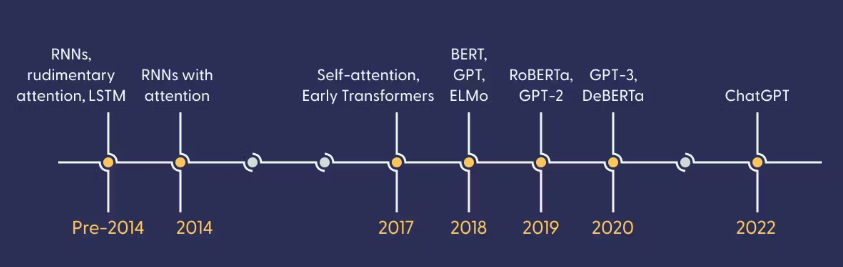

In [ ]:
tf.keras.preprocessing.image.load_img(os.path.join(images_path, 'history_of_language_models.png'))

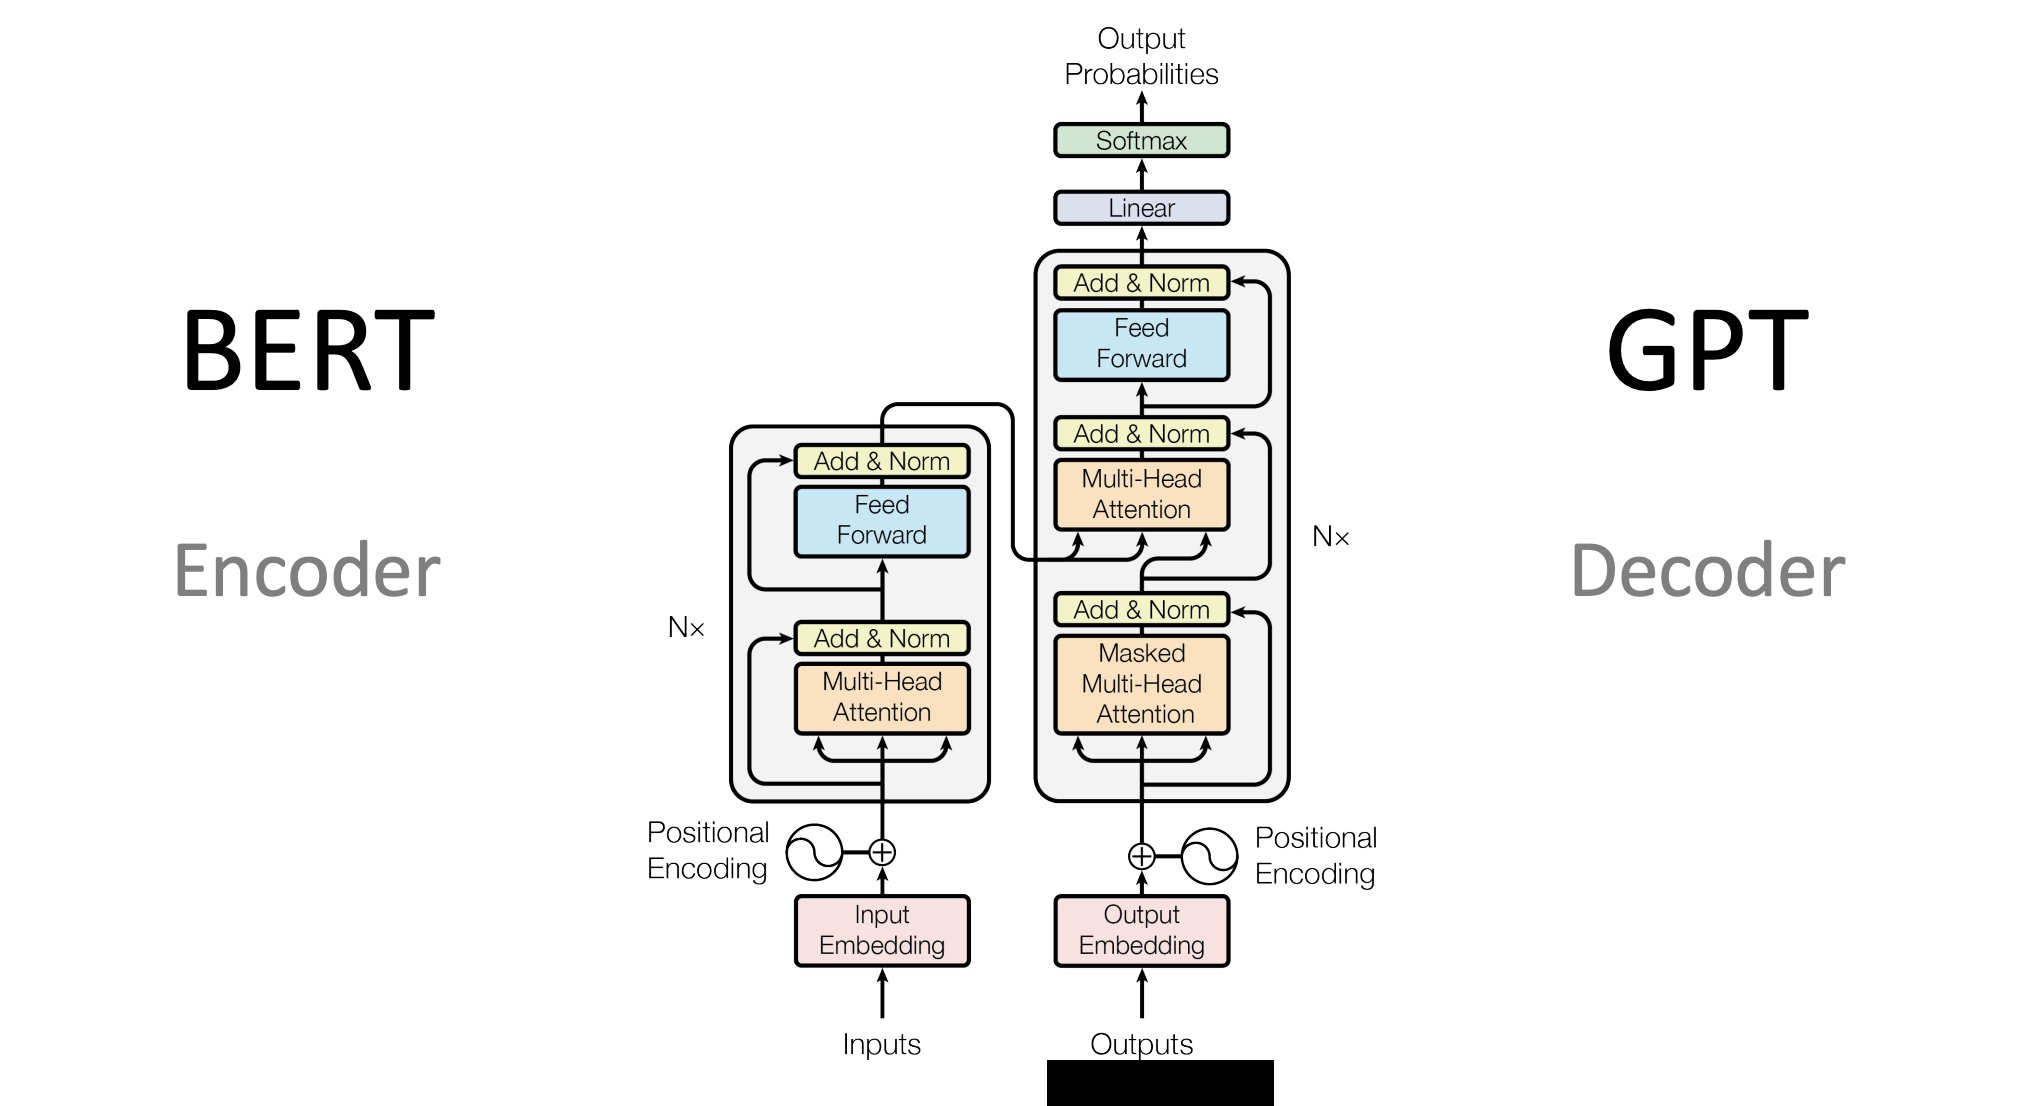

In [ ]:
tf.keras.preprocessing.image.load_img(os.path.join(images_path, 'bert_vs_gpt_in_transformer.png'))

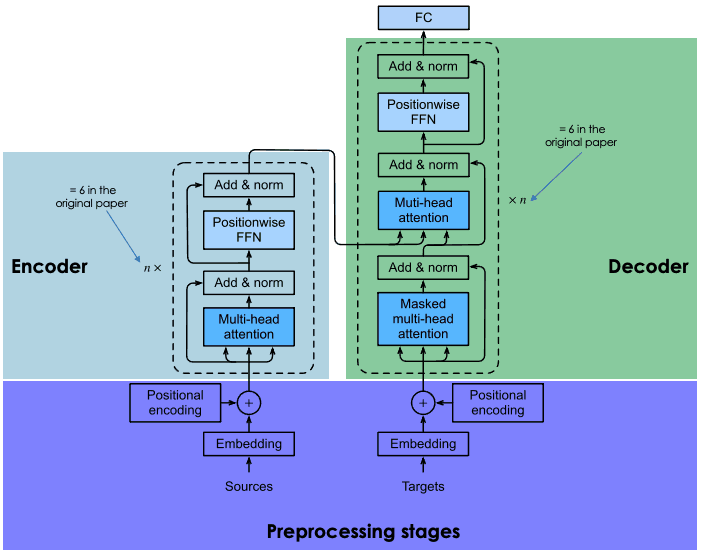

In [ ]:
tf.keras.preprocessing.image.load_img(os.path.join(images_path, 'encoder_decoder_preprocessing_stages_transformer.png'))

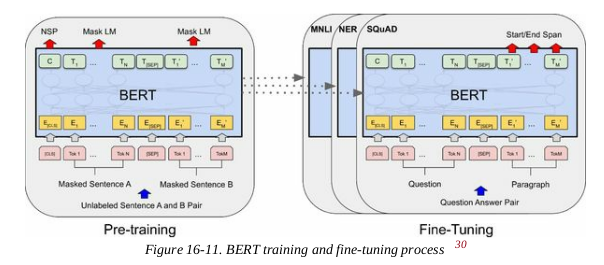

In [ ]:
tf.keras.preprocessing.image.load_img(os.path.join(images_path, 'BERT_training_and_fine_tuning.png'))

## FinBERT

- FinBERT is a BERT model pre-trained on financial communication text. The purpose is to enhance financial NLP research and practice. It is trained on the following three financial communication corpus. The total corpora size is 4.9B tokens.

  - Corporate Reports 10-K & 10-Q: 2.5B tokens
  - Earnings Call Transcripts: 1.3B tokens
  - Analyst Reports: 1.1B tokens

- <a href="https://huggingface.co/ProsusAI/finbert">ProsusAI FinBERT</a> and the project's <a href="https://github.com/ProsusAI/finBERT">GitHub</a> from the investment group <a href="https://www.prosus.com/">Prosus</a> (see their <a href="https://en.wikipedia.org/wiki/Prosus">Wiki</a>).  

---
---
---


- Initial paper:

  - <a href="https://arxiv.org/pdf/1908.10063.pdf">FinBERT: Financial Sentiment Analysis with Pre-trained Language Models</a>

- More comprehensive paper:

  - <a href="https://onlinelibrary.wiley.com/doi/epdf/10.1111/1911-3846.12832">FinBERT: A Large Language Model for Extracting Informationfrom Financial Text</a>

In [ ]:
# Use a pipeline as a high-level helper
from transformers import pipeline
import transformers

In [ ]:
model = pipeline("text-classification", model="ProsusAI/finbert")

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:88: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [ ]:
model("the growth is strong due to uncertainty")

[{'label': 'positive', 'score': 0.8531723618507385}]

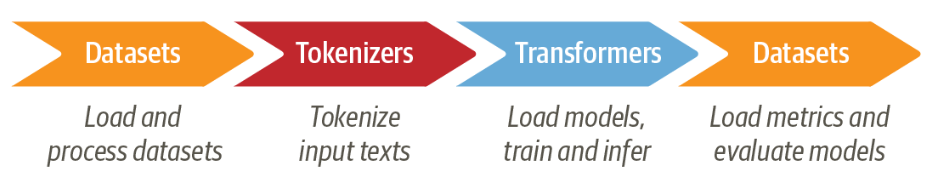

In [ ]:
tf.keras.preprocessing.image.load_img(os.path.join(images_path, 'hugging_face_pipeline.png'))

In [ ]:
# You can also "manually" load the model
from transformers import AutoTokenizer, AutoModelForSequenceClassification

tokenizer = AutoTokenizer.from_pretrained("ProsusAI/finbert")
model = AutoModelForSequenceClassification.from_pretrained("ProsusAI/finbert")

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:88: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

In [ ]:
model

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [ ]:
nlp = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer)

In [ ]:
sentences = ["there is a shortage of capital, and we need extra financing",
             "growth is strong and we have plenty of liquidity",
             "there are doubts about our finances",
             "profits are flat"]
results = nlp(sentences)

results  #LABEL_0: neutral; LABEL_1: positive; LABEL_2: negative

[{'label': 'negative', 'score': 0.8653576970100403},
 {'label': 'positive', 'score': 0.9025793075561523},
 {'label': 'neutral', 'score': 0.4569743573665619},
 {'label': 'neutral', 'score': 0.7185564637184143}]

## <a href="https://huggingface.co/yiyanghkust/finbert-tone">FinBERT-Tone: Fine-Tuning FinBERT</a>

- Like many transformer models, the original FinBERT model has been fine-tuned to increase specific task performance.

- <b>finbert-tone</b> model is the FinBERT model fine-tuned on 10,000 manually annotated (positive, negative, neutral) sentences from analyst reports.

- This model achieves superior performance on <b>financial tone analysis</b> task.

- For more on finbert-tone, see <a href="https://huggingface.co/yiyanghkust/finbert-tone">Hugging Face's model card</a> and <a href="https://github.com/yya518/FinBERT">the model's GitHub</a>.

In [ ]:
import tensorflow as tf
from transformers import TFAutoModelForSequenceClassification, AutoTokenizer

In [ ]:
# "Manually" load the pre-trained FinBERT model and tokenizer
model_name = "yiyanghkust/finbert-tone"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = TFAutoModelForSequenceClassification.from_pretrained(model_name)

config.json:   0%|          | 0.00/533 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/226k [00:00<?, ?B/s]

tf_model.h5:   0%|          | 0.00/439M [00:00<?, ?B/s]

All model checkpoint layers were used when initializing TFBertForSequenceClassification.

All the layers of TFBertForSequenceClassification were initialized from the model checkpoint at yiyanghkust/finbert-tone.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertForSequenceClassification for predictions without further training.


In [ ]:
news_headlines = [
    "Stocks surge as company beats earnings expectations",
    "Investors concerned about inflation and rising interest rates",
    "New product launch boosts company's stock price",
    "Analysts downgrade tech sector amid regulatory concerns"
]

In [ ]:
# Tokenize and encode the news headlines
inputs = tokenizer(news_headlines, padding=True, return_tensors="tf")

inputs

{'input_ids': <tf.Tensor: shape=(4, 12), dtype=int32, numpy=
array([[    3,   924,  9586,    18,    37, 23518,   149,   746,     4,
            0,     0,     0],
       [    3,   311,  3771,    94,  2122,     8,  1887,    68,   240,
            4,     0,     0],
       [    3,    56,   108,  1348,  4088,    63,    37,  5674,    58,
           93,   101,     4],
       [    3,   857,  5144,  4579,  1058, 13280,   257,  2055,     4,
            0,     0,     0]], dtype=int32)>, 'token_type_ids': <tf.Tensor: shape=(4, 12), dtype=int32, numpy=
array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], dtype=int32)>, 'attention_mask': <tf.Tensor: shape=(4, 12), dtype=int32, numpy=
array([[1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0]], dtype=int32)

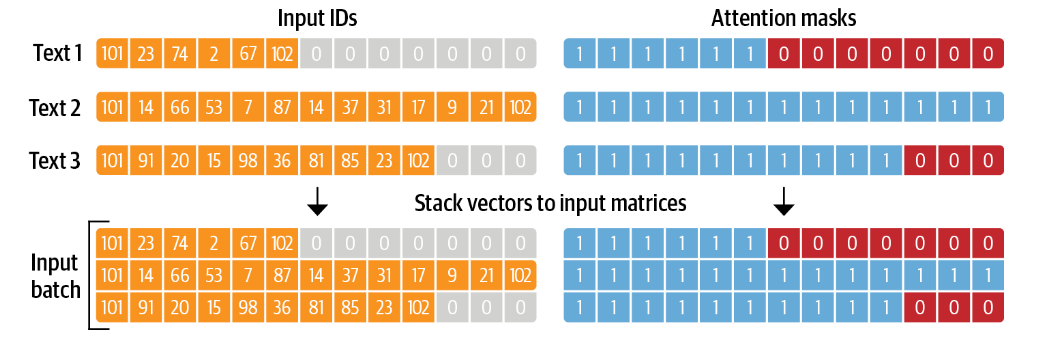

In [ ]:
tf.keras.preprocessing.image.load_img(os.path.join(images_path, 'tokenization_and_attention_masks.png'))

In [ ]:
tokenizer.convert_ids_to_tokens(inputs['input_ids'].numpy()[0])

['[CLS]',
 'stocks',
 'surge',
 'as',
 'company',
 'beats',
 'earnings',
 'expectations',
 '[SEP]',
 '[PAD]',
 '[PAD]',
 '[PAD]']

In [ ]:
tokenizer.convert_ids_to_tokens(inputs['input_ids'].numpy()[1])

['[CLS]',
 'investors',
 'concerned',
 'about',
 'inflation',
 'and',
 'rising',
 'interest',
 'rates',
 '[SEP]',
 '[PAD]',
 '[PAD]']

In [ ]:
tokenizer.convert_ids_to_tokens(inputs['input_ids'].numpy()[2])

['[CLS]',
 'new',
 'product',
 'launch',
 'boost',
 '##s',
 'company',
 "'",
 's',
 'stock',
 'price',
 '[SEP]']

- We can observe three things here.

  - First, some special [CLS] and [SEP] tokens have been added to the start and end of the sequence.

  - These tokens differ from model to model, but their main role is to indicate the start and end of a sequence.

  - Second, the tokens have each been lowercased, which is a feature of this particular checkpoint.

  - Finally, we can see that some of the words have been split into two tokens.

- Also, recall a logit is the log-odds of a probability:$$logit(p) = \ln\left(\frac{p}{1-p}\right).$$

$\square$

In [ ]:
# Perform sentiment analysis using FinBERT
outputs = model(inputs)

outputs

TFSequenceClassifierOutput(loss=None, logits=<tf.Tensor: shape=(4, 3), dtype=float32, numpy=
array([[-7.271548  , 12.878894  , -6.9779873 ],
       [-0.98071504, -5.553596  ,  9.812591  ],
       [-7.995548  , 13.319205  , -6.271116  ],
       [-4.623462  , -2.3474054 , 10.339322  ]], dtype=float32)>, hidden_states=None, attentions=None)

In [ ]:
Y_probabilities = tf.keras.activations.softmax(outputs.logits)

Y_probabilities

<tf.Tensor: shape=(4, 3), dtype=float32, numpy=
array([[1.7732672e-09, 1.0000000e+00, 2.3782993e-09],
       [2.0536103e-05, 2.1210022e-07, 9.9997926e-01],
       [5.5350380e-10, 1.0000000e+00, 3.1047873e-09],
       [3.1750022e-07, 3.0918809e-06, 9.9999654e-01]], dtype=float32)>

In [ ]:
# Interpret results
predicted_labels = tf.argmax(outputs.logits, axis=1)

predicted_labels

<tf.Tensor: shape=(4,), dtype=int64, numpy=array([1, 2, 1, 2])>

In [ ]:
sentiment_labels = ["Negative", "Neutral", "Positive"]

In [ ]:
sentiments = [sentiment_labels[label] for label in predicted_labels.numpy()]

sentiments

['Neutral', 'Positive', 'Neutral', 'Positive']

In [ ]:
# Print results
for headline, sentiment in zip(news_headlines, sentiments):
    print(f"Headline: {headline}")
    print(f"Sentiment: {sentiment}\n")

Headline: Stocks surge as company beats earnings expectations
Sentiment: Neutral

Headline: Investors concerned about inflation and rising interest rates
Sentiment: Positive

Headline: New product launch boosts company's stock price
Sentiment: Neutral

Headline: Analysts downgrade tech sector amid regulatory concerns
Sentiment: Positive



In [ ]:
### Example from Model Card
from transformers import BertTokenizer, BertForSequenceClassification
from transformers import pipeline

finbert = BertForSequenceClassification.from_pretrained('yiyanghkust/finbert-tone',num_labels=3)
tokenizer = BertTokenizer.from_pretrained('yiyanghkust/finbert-tone')

nlp = pipeline("sentiment-analysis", model=finbert, tokenizer=tokenizer)

sentences = ["there is a shortage of capital, and we need extra financing",
             "growth is strong and we have plenty of liquidity",
             "there are doubts about our finances",
             "profits are flat"]
results = nlp(sentences)

results  #LABEL_0: neutral; LABEL_1: positive; LABEL_2: negative


pytorch_model.bin:   0%|          | 0.00/439M [00:00<?, ?B/s]

[{'label': 'Negative', 'score': 0.9966173768043518},
 {'label': 'Positive', 'score': 1.0},
 {'label': 'Negative', 'score': 0.9999710321426392},
 {'label': 'Neutral', 'score': 0.9889442920684814}]

$\rule{800pt}{20pt}$

# Why Is It Called A <a href="https://blogs.nvidia.com/blog/what-is-a-transformer-model/">Transformer</a>?

- Recall: a transformer model is a neural network that learns context by tracking relationships in sequential data.

- Attention is so key to transformers that the Google researchers that wrote the paper almost used the term and coined the models: <b>AttentionNet</b>.

- However Ashish Vaswani (USC CS PhD in 2014, and started working on neural networks in 2011) thought that "AttentionNet didn't sound very exciting".

- It was Jakob Uszkoreit, a senior software engineer on the team, who came up with the name <b>Transformer</b>.

- Vaswani added, "I argued we were <b>transforming representations</b>, but that was just playing semantics."

  - Thanks to a basket of techniques, the authors trained their model in just 3.5 days on eight NVIDIA GPUs.
  
    - This was a small fraction of the time and cost of training prior models.
    
    - They trained it on datasets with up to a billion pairs of words.

- <a href="https://blogs.nvidia.com/blog/gtc-2024-transformer-ai-research-panel-jensen/"><b>Let's read the origins of the transformer model, together</b></a>    

$\rule{800pt}{20pt}$

# Text Generation

In [ ]:
import transformers

In [ ]:
text_generation_model = transformers.pipeline("text-generation", model="gpt2")

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:88: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [ ]:
prompt = "Hello"

generated_text = text_generation_model(prompt)
#, num_return_sequences=1, temperature=0.7 (controls the randomness of the generation), max_length=50, truncation=True, do_sample=True,

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


In [ ]:
generated_text

[{'generated_text': "Hello?\n\nThe way you do it in the app is a simple way:\n\nimport React, { Component } from'react'; import { createApp } from './createApp'; export default class App { render(){ return () =>"}]

In [ ]:
print(generated_text[0]['generated_text'])

Hello?

The way you do it in the app is a simple way:

import React, { Component } from'react'; import { createApp } from './createApp'; export default class App { render(){ return () =>


$\rule{800pt}{10pt}$

In [ ]:
%%time

generator = pipeline('text-generation', model = 'HuggingFaceH4/zephyr-7b-beta')

config.json:   0%|          | 0.00/638 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

model-00001-of-00008.safetensors:   0%|          | 0.00/1.89G [00:00<?, ?B/s]

model-00002-of-00008.safetensors:   0%|          | 0.00/1.95G [00:00<?, ?B/s]

model-00003-of-00008.safetensors:   0%|          | 0.00/1.98G [00:00<?, ?B/s]

...

model-00005-of-00008.safetensors:   0%|          | 0.00/1.98G [00:00<?, ?B/s]

model-00006-of-00008.safetensors:   0%|          | 0.00/1.95G [00:00<?, ?B/s]

model-00007-of-00008.safetensors:   0%|          | 0.00/1.98G [00:00<?, ?B/s]

model-00008-of-00008.safetensors:   0%|          | 0.00/816M [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/8 [00:00<?, ?it/s]

In [ ]:
generator("Hello, I'm a language model", max_length = 30, num_return_sequences=3)
## [{'generated_text': "Hello, I'm a language modeler. So while writing this, when I went out to meet my wife or come home she told me that my"},
##  {'generated_text': "Hello, I'm a language modeler. I write and maintain software in Python. I love to code, and that includes coding things that require writing"}, ...

$\rule{800pt}{10pt}$

In [ ]:
%%time

text2text_generator = transformers.pipeline("text2text-generation")

In [ ]:
text2text_generator("question: What is 42 ? context: 42 is the answer to life, the universe and everything")
# [{'generated_text': 'the answer to life, the universe and everything'}]

In [ ]:
text2text_generator("translate from English to French: I'm very happy")
# [{'generated_text': 'Je suis très heureux'}]

$\rule{800pt}{20pt}$

$\rule{800pt}{20pt}$

# The Rise of Open LLMs

- February 2023: LLaMa

- March: Alpaca, Vicuna

- April: Koala

- May: StarCoder, StarChat, MPT-7B, Guanaco

- June: Falcon, MPT-30B, Phi-1

- July: LLaMa-2

- September: Falcon 180B, Mistral-7b

- November: Yi-34B, Zephyr-7b

- December 2023: Mixtral-8x7b, Phi-2

- ... and the race continues!

- See <a href="https://alphasignal.ai/">AlphaSignal AI Newsletter</a> to stay up-to-date.

---
---
---

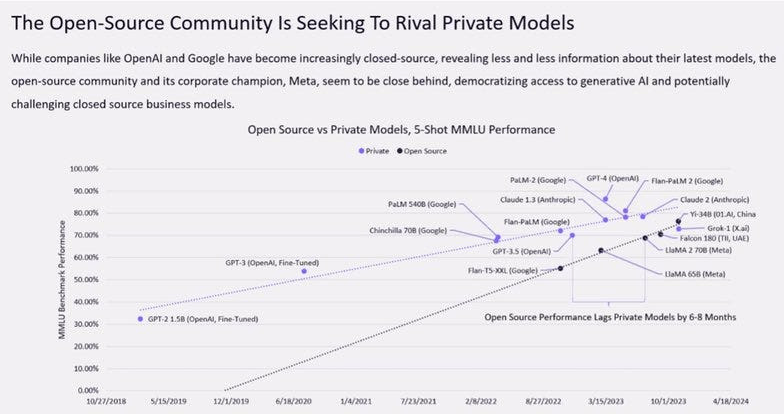

In [ ]:
tf.keras.preprocessing.image.load_img(os.path.join(images_path, 'open_source_vs_private_llms.png'))

- <a href="https://huggingface.co/open-llm-leaderboard">Hugging Face's Open LLM Leaderboard Community</a>:

  - This is the hub organisation maintaining the <a href="https://huggingface.co/spaces/HuggingFaceH4/open_llm_leaderboard">Open LLM Leaderboard</a>.

  - In this space you will find the dataset with detailed results and queries for the models on the leaderboard.

  - This hub serves as a a public leaderboard comparing open access large language models, and is a wrapper running the open-source benchmarking library <a href="https://github.com/EleutherAI/lm-evaluation-harness">Eleuther AI's Language Model Evaluation Process</a>.

  - This wrapper runs evaluations using the Eleuther AI harness on the spare cycles of Hugging Face's compute cluster, and stores the results in a dataset on the hub that are then displayed on the leaderboard online space.

    - This project provides a unified framework to test generative language models on a large number of different evaluation tasks.

      - Over 60 standard academic benchmarks for LLMs, with hundreds of subtasks and variants implemented.
      
      - Support for models loaded via transformers (including quantization via AutoGPTQ), GPT-NeoX, and Megatron-DeepSpeed, with a flexible tokenization-agnostic interface.

      - Support for fast and memory-efficient inference with vLLM.

      - Support for commercial APIs including OpenAI, and TextSynth.
      
      - Support for evaluation on adapters (e.g. LoRA) supported in HuggingFace's PEFT library.
      
      - Support for local models and benchmarks.
      
      - Evaluation with publicly available prompts ensures reproducibility and comparability between papers.
      
      - Easy support for custom prompts and evaluation metrics.
    
    - <b>The Language Model Evaluation Harness is the backend for 🤗 Hugging Face's popular <a href="https://huggingface.co/spaces/HuggingFaceH4/open_llm_leaderboard">Open LLM Leaderboard</a>, and is used internally by dozens of organizations including NVIDIA, Cohere, BigScience, BigCode, Nous Research, and Mosaic ML.</b>


- For more, see: <a href="https://huggingface.co/blog/open-llm-leaderboard-mmlu">What's Going on with the Open LLM Leaderboard?</a>

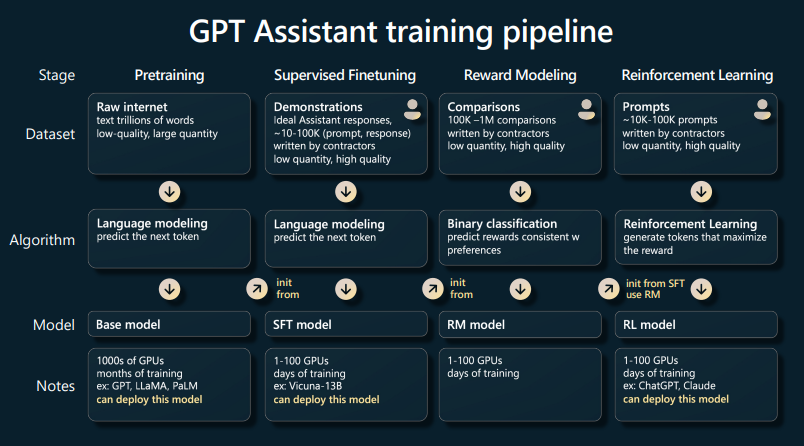

In [ ]:
tf.keras.preprocessing.image.load_img(os.path.join(images_path, 'gpt_assistant_training_pipeline.png'))

- See <a href="https://karpathy.ai/stateofgpt.pdf">Andrej Karpathy's State of GPT as of May 2023</a>.

- See <a href="https://www.linkedin.com/pulse/beginners-guide-creating-high-performing-models-using-qdqgf/">Comparing Fine-Tuning, RLHF, and RAG as techniques for improving the performance of pretrained LLMs.</a>

## Training LLMs

- Pretraining

  - goal is to predict the next token

  - typically done by large organizations (OpenAI, Meta, Google, etc.)

  - training happens across clusters of GPUs

    - GPT-4: 25,000 GPUs for 100 days

    - LLaMa-2 70B: 6,000 GPUs for 12 days

  - costs millions of dollars and results in a <i>foundational (base) model</i>

- Supervised fine-tuning (SFT)

  - turns the foundational model into a chatbot

    - 1k-100k input-output pairs

    - one or more GPUs that can be run through a cloud-service provider

    - <a href="https://huggingface.co/docs/trl/en/index">Hugging Face's (TRL) Transormer Reinforcement Learning</a> for supervised fine-tuning

- Human Preference Training (RLHF)

  - <a href="https://aws.amazon.com/what-is/reinforcement-learning-from-human-feedback/">What is RLHF?</a>

  - make the chatbot perform in ways that seem to be <i>friendly</i>, <i>harmless</i>, <i>helpful</i>, etc.

- RAG Training

  - <a href="https://aws.amazon.com/what-is/retrieval-augmented-generation/">What is RAG?</a>

- For more, see <a href="https://cameronrwolfe.substack.com/p/self-critique-self-rag-neftune-safe">Self-Critique, Self-RAG, NEFTune, Safe RLHF and More (as of 8/23)</a>

## Deploying LLMs

- Serverless compute

  - <b>charge per token</b>

    - i.e. \$0.0006/1K tokens for the <a href="https://huggingface.co/mistralai/Mixtral-8x7B-v0.1">Mixtral-8x7B</a> model; for the paper, see <a href="https://arxiv.org/pdf/2401.04088.pdf">here</a> (which is more than 60\% cheaper than GPT-3.5)


- Dedicated compute

  - <b>charge per time</b>

    - i.e. \$2/hour, and they give Text Generation Inference (TGI), virtual LLMs, and inference endpoints

## Benefits of Open and Closed Source

- Why open source?

  - access to the model

  - fine-tuning

  - run at the edge (on devices)

  - no private data is being sent to another party (private)

  - however performance may be subpar without fine-tuning and there are costs to deploy (a steep learning curve)

- Why closed source?

  - everything is handled for you (you only pay per tokens)

  - will have good performance

  - however the underlying model might change without you knowing, which could impact prompting, data is being sent to another party

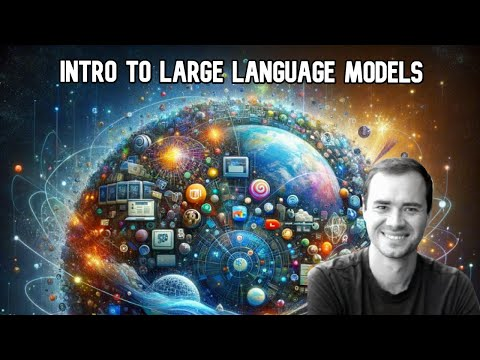

In [ ]:
from IPython.display import YouTubeVideo
# https://www.youtube.com/watch?v=zjkBMFhNj_g
YouTubeVideo('zjkBMFhNj_g', width=900, height=600)

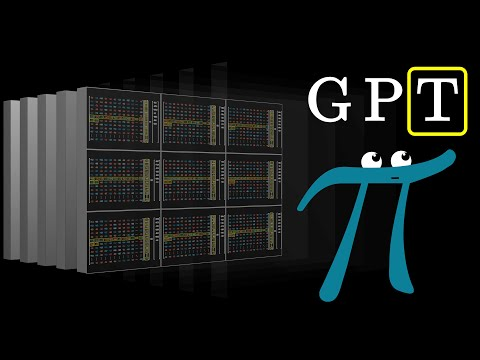

In [ ]:
from IPython.display import YouTubeVideo
# https://www.youtube.com/watch?v=wjZofJX0v4M&list=PLZHQObOWTQDNU6R1_67000Dx_ZCJB-3pi&index=6
YouTubeVideo('wjZofJX0v4M', width=900, height=600)

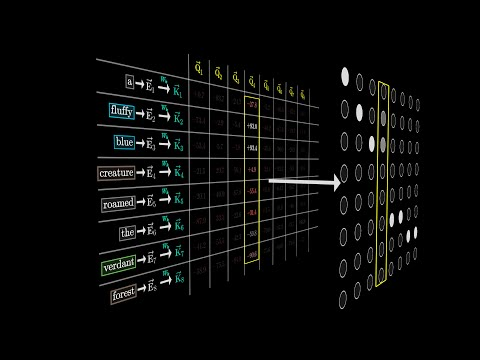

In [ ]:
from IPython.display import YouTubeVideo
# https://www.youtube.com/watch?v=eMlx5fFNoYc&list=PLZHQObOWTQDNU6R1_67000Dx_ZCJB-3pi&index=6
YouTubeVideo('eMlx5fFNoYc', width=900, height=600)

## Open-Source <a href="https://en.wikipedia.org/wiki/Mixture_of_experts">Mixture of Experts</a>

- <a href="https://huggingface.co/mistralai/Mixtral-8x7B-v0.1">mistralai/Mixtral-8x7B-v0.1</a>

  - <a href="https://huggingface.co/docs/transformers/en/model_doc/mixtral">Hugging Face: Mixtral Documentations</a>

- <a href="https://mistral.ai/news/mixtral-of-experts/">Mistral AI_: Mixtral of Experts, A high quality Sparse Mixture-of-Experts</a>, and the <a href="https://arxiv.org/pdf/2401.04088.pdf">full paper</a>.



In [ ]:
# Use a pipeline as a high-level helper
from transformers import pipeline

pipe = pipeline("text-generation", model="mistralai/Mixtral-8x7B-v0.1")

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:88: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/720 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/92.7k [00:00<?, ?B/s]

model-00001-of-00019.safetensors:   0%|          | 0.00/4.89G [00:00<?, ?B/s]

model-00002-of-00019.safetensors:   0%|          | 0.00/4.98G [00:00<?, ?B/s]

...

/usr/local/lib/python3.10/dist-packages/huggingface_hub/file_download.py:983: UserWarning: Not enough free disk space to download the file. The expected file size is: 4983.00 MB. The target location /root/.cache/huggingface/hub only has 3266.05 MB free disk space.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/huggingface_hub/file_download.py:983: UserWarning: Not enough free disk space to download the file. The expected file size is: 4983.00 MB. The target location /root/.cache/huggingface/hub/models--mistralai--Mixtral-8x7B-v0.1/blobs only has 3266.05 MB free disk space.
  warnings.warn(


model-00018-of-00019.safetensors:   0%|          | 0.00/4.98G [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/huggingface_hub/file_download.py:983: UserWarning: Not enough free disk space to download the file. The expected file size is: 4983.00 MB. The target location /root/.cache/huggingface/hub only has 0.00 MB free disk space.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/huggingface_hub/file_download.py:983: UserWarning: Not enough free disk space to download the file. The expected file size is: 4983.00 MB. The target location /root/.cache/huggingface/hub/models--mistralai--Mixtral-8x7B-v0.1/blobs only has 0.00 MB free disk space.
  warnings.warn(


model-00018-of-00019.safetensors:   0%|          | 0.00/4.98G [00:00<?, ?B/s]

ValueError: Could not load model mistralai/Mixtral-8x7B-v0.1 with any of the following classes: (<class 'transformers.models.auto.modeling_auto.AutoModelForCausalLM'>, <class 'transformers.models.auto.modeling_tf_auto.TFAutoModelForCausalLM'>, <class 'transformers.models.mixtral.modeling_mixtral.MixtralForCausalLM'>). See the original errors:

while loading with AutoModelForCausalLM, an error is thrown:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/transformers/pipelines/base.py", line 279, in infer_framework_load_model
    model = model_class.from_pretrained(model, **kwargs)
  File "/usr/local/lib/python3.10/dist-packages/transformers/models/auto/auto_factory.py", line 561, in from_pretrained
    return model_class.from_pretrained(
  File "/usr/local/lib/python3.10/dist-packages/transformers/modeling_utils.py", line 3264, in from_pretrained
    resolved_archive_file, sharded_metadata = get_checkpoint_shard_files(
  File "/usr/local/lib/python3.10/d

- <a href="https://huggingface.co/docs/transformers/generation_strategies">Hugging Face: Transformers documentation -> Text generation strategies</a>

  - <i>do_sample : if set to True , this parameter enables decoding strategies such as multinomial sampling, beam-search multinomial sampling, Top-K sampling and Top-p sampling. All these strategies select the next token from the probability distribution over the entire vocabulary with various strategy-specific adjustments.</i>

In [ ]:
prompt = "Hello my name is"

generated_text = pipe(prompt, max_length=50) # do_sample=True

In [ ]:
generated_text

In [ ]:
print(generated_text[0]['generated_text'])

$\rule{800pt}{20pt}$

$\rule{800pt}{20pt}$

# What Have We Covered?
<br>
<font size="+1">
  <ol>
    <li>We have discussed what generative AI is and compared it to discriminitive modeling techniques.</li>
    <br>
    <li>We have discussed the economics of large-scale language models in practice.</li>
    <br>
    <li>We saw how to use some basic and advanced functionality of the Hugging Face API.</li>
    <br>
    <li>We also discussed the rise of open LLMs.</li>
    <br>
  </ol>
</font>



$\rule{800pt}{20pt}$

# Miscellaneous: NOT NECESSARY TO KNOW

<br>
<font size="+1">
  <ol>
    <li><details>
    <summary>This is an example of using the HTML details tag.</summary>
    And here is more exposition.
    </details></li>
    <br>
  </ol>
</font>


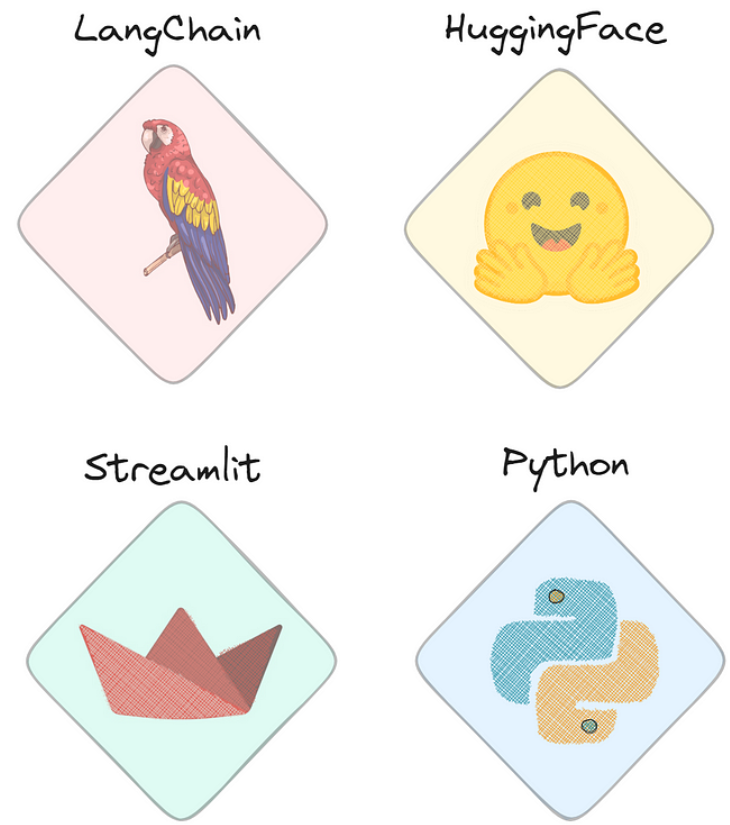

In [ ]:
tf.keras.preprocessing.image.load_img(os.path.join(images_path, 'modern_AI_stack.png'))

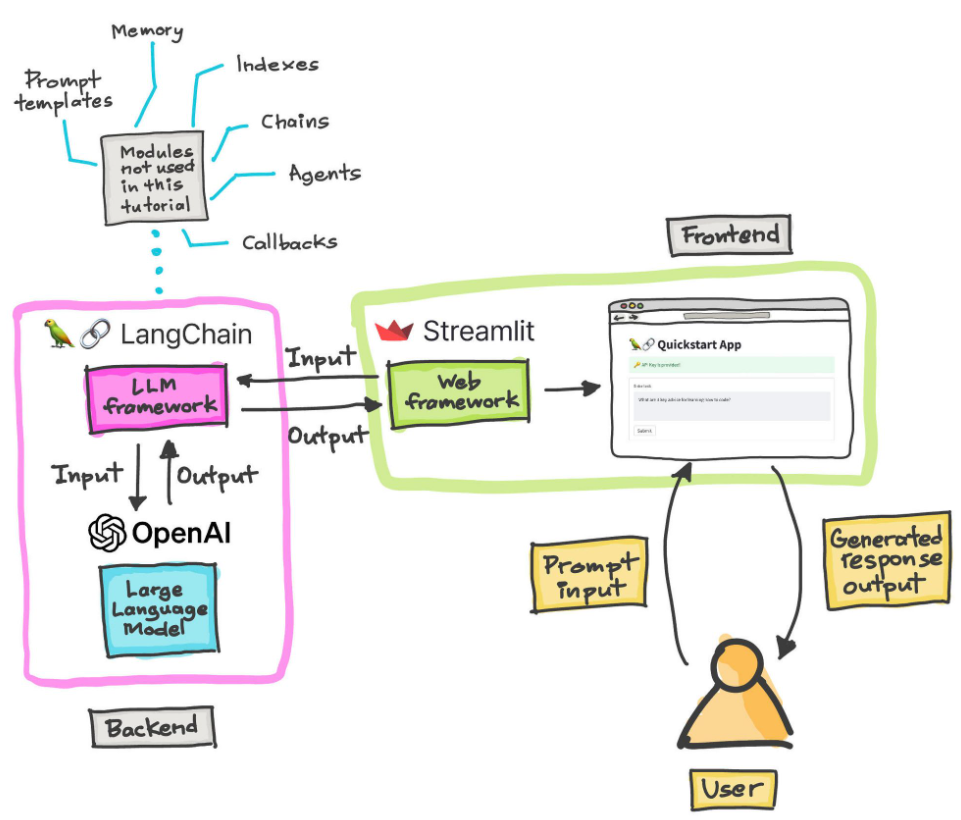

In [ ]:
tf.keras.preprocessing.image.load_img(os.path.join(images_path, 'modern_AI_stack_2.png'))

## Embeddings

- Deep Learning finds its strength in its ability to model efficiently with different types of data at once.

It is trivial to build models from multimodal datasets nowadays.

It is not a new concept, though, nor was it impossible to do it prior to the advent of DL, but the level of complexity of feature processing and modeling was much higher with much lower performance levels!

One key aspect of this success is the concept of Embedding: a lower dimensionality representation of the data.

This makes it possible to perform efficient computations while minimizing the effect of the curse of dimensionality and providing more robust representations when it comes to overfitting.

In practice, this is just a vector living in a "latent" or "semantic" space.

The first great success of embedding for word encoding was Word2Vec back in 2013 and later GloVe in 2014.

Since AlexNet back in 2012, many Convolutional network architectures (VGG16 (2014), ResNet (2015), Inception (2014), …) have been used as feature extractors for images.

As of 2018, starting with BERT, Transformer architectures have been used quite a bit to extract semantic representations from sentences.

One domain where embeddings changed everything is recommender engines.

It all started with Latent Matrix Factorization methods made popular during the Netflix competition in 2009.

The idea is to have a vector representation for each user and product and use that as base features.

In fact, any sparse feature could be encoded within an embedding vector, and modern rec engines typically use hundreds of embedding matrices for different categorical variables.

Dimensionality reduction is by all accounts not a new concept in Unsupervised Learning!

PCA, for example, dates back to 1901; the concept of Autoencoder was introduced in 1986, and the variational Autoencoders (VAE) were introduced in 2013.

For example, VAE is a key component of Stable Diffusion.

The typical difficulty with Machine Learning is the ability to have labeled data.

Self-supervised learning techniques like Word2Vec, Autoencoders, and generative language models allow us to build powerful latent representations of the data at a low cost.

Meta came out with Data2Vec 2.0 to learn latent representations of any data modality using self-supervised learning.

Besides learning latent representations, a lot of work is being done to learn aligned representations between different modalities.

For example, CLIP is a recent contrastive learning method to learn semantically aligned representations between text and image data.

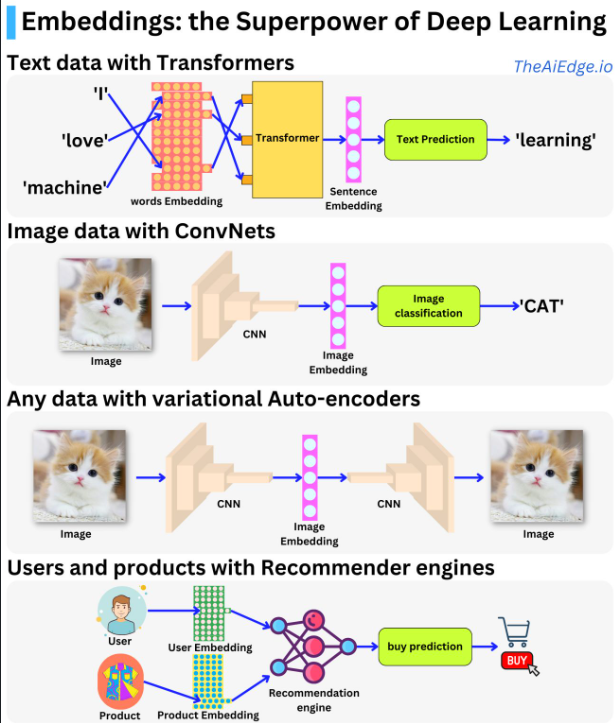

In [ ]:
tf.keras.preprocessing.image.load_img(os.path.join(images_path, 'embeddings_for_deep_learning.png'))

## Masking
<br>
<font size="+1">
  <ul>
    <li></li>
    <br>
  </ul>
</font>

$\square$

In [ ]:
# inputs = tf.keras.layers.Input(shape=[], dtype=tf.string)

# token_ids = text_vec_layer(inputs)

# mask = tf.math.not_equal(token_ids, 0)

# Z = tf.keras.layers.Embedding(vocab_size, embed_size)(token_ids)
# Z = tf.keras.layers.GRU(128, dropout=0.2)(Z, mask=mask)

# outputs = tf.keras.layers.Dense(1, activation="sigmoid")(Z)

# model = tf.keras.Model(inputs=[inputs], outputs=[outputs])

In [ ]:
# text_vec_layer_ragged = tf.keras.layers.TextVectorization(max_tokens=vocab_size, ragged=True)

# text_vec_layer_ragged.adapt(train_set.map(lambda reviews, labels: reviews))

In [ ]:
# text_vec_layer_ragged(["Great movie!", "This is DiCaprio's best role."])

In [ ]:
# text_vec_layer(["Great movie!", "This is DiCaprio's best role."])

## Reusing Pretrained Embeddings and Pretrained Language Models
<br>
<font size="+1">
  <ul>
    <li>Can we improve our embeddings by reusing word embeddings trained on some other very large set of text such as Amazon reviews (available on TF datasets).</li>
    <br>
    <li>Its possible embeddings would be useful for sentiment analysis even if they were trained on another task since words like <i>awesome</i> and <i>amazing</i> have similar meanings, which means they will likely cluster in the embedding space even for tasks such as predicting the next word in a sentence.</li>
    <br>
    <ul>
      <li>If all positive words and all negative words form clusters, then this will be helpful for sentiment analysis.</li>
      <br>
    </ul>
    <li>Instead of training word embeddings, we could just download and use pretrained embeddings, such as:</li>
    <br>
    <ul>
      <li>Google's Word2Vec embeddings,</li>
      <br>
      <li>Stanford's GloVe embeddings,</li>
      <br>
      <li>Facebook's FastText embeddings,</li>
      <br>
      <li>etc.</li>
      <br>
    </ul>
    <li>Using pretrained word embeddings was popular for several years, but this approach has its limits.</li>
    <br>
    <ul>
      <li>In particular, a word has a single representation, no matter the context.</li>
      <br>
      <li>For example, the word <i>"right"</i> is encoded the same way in <i>"left and right"</i> and <i>"right and wrong"</i>, even though it means two very different things.</li>
      <br>
    </ul>
    <li>In a 2018 paper, <a href="https://paperswithcode.com/method/elmo">Embeddings from Language Models (ELMo)</a>, the authors introduced contextualized word embeddings, which are learned from the internal states of a deep bidirectional language model.</li>
    <br>
    <ul>
      <li>You reuse part of a pretrained language model, rather than just using pretrained embeddings.</li>
      <br>
    </ul>
    <li>Also in 2018, the paper <a href="https://paperswithcode.com/method/ulmfit">Universal Language Model Fine-Tuning (ULMFiT)</a> demonstrated the effectiveness of unsupervised pretraining for NLP tasks.</li>
    <br>
    <ul>
      <li>The authors trained an LSTM language model on a huge set of text using self-supervised learning, i.e. generating the labels automatically from the data.</li>
      <br>
      <li>Then, they fine-tuned the LSTM model on particular tasks.</li>
      <br>
      <li>Their model outperformed the state-of-the-art on six text classification tasks by a large margin, reducing error rate by 18-24%.</li>
      <br>
      <li>They also showed a pretrained model fine-tuned on just 100 labeled examples could achieve the same performance as one trained from scratch on 10,000 examples.</li>
      <br>
    </ul>
    <font color="red"><li>Before the ULMFiT paper, using pretrained models was only the norm in computer vision, and in the context of NLP, pretraining was limited to word embeddings. The paper marked the beginning of a new era in NLP; today, reusing pretrained language models is the norm.</li></font>
    <br>
    <ul>
      <li>As an example, let's build a classifier based on the Universal Sentence Encoder, which is a model architecture introduced in the 2018 paper <a href="https://arxiv.org/abs/1803.11175">Universal Sentence Encoder</a> by a team of Google researchers.</li>
      <br>
      <li>This model is based on the transformer architecture, which we will discuss later.</li>
      <br>
      <li>Conveniently, this model is available on <a href="https://www.tensorflow.org/hub/tutorials/semantic_similarity_with_tf_hub_universal_encoder">TensorFlow Hub</a>.</li>
      <br>
    </ul>
  </ul>
</font>

$\square$

In [ ]:
# import os
# import tensorflow_hub as hub

# os.environ['TFHUB_CACHE_DIR'] = "my_tfhub_cache"

# model = tf.keras.Sequential([
#     hub.KerasLayer("https://tfhub.dev/google/universal-sentence-encoder/4", trainable=True, dtype=tf.string, input_shape=[])
#     tf.keras.layers.Dense(64, activation="relu")
#     tf.keras.layers.Dense(1, activation="sigmoid")
# ])

# model.compile(loss="binary_crossentropy", optimizer="nadam", metrics=["accuracy"])

# model.fit(train_set, validation_data=valid_set, epochs=10)

<br>
<font size="+1">
  <ul>
    <li>The model is quite large, close to 1 GB in size, so it may take a while to download.</li>
    <br>
    <li>By default, TensorFlow Hub modules are saved to a temporary directory, and they get downloaded again and again every time you run your program.</li>
    <br>
    <li>To avoid that, you must set the <b>TFHUB_CACHE_DIR</b> environment variable to a directory of your choice, which will allow the modules to be saved there, and only downloaded once.</li>
    <br>
    <li>Note that we set <b>trainable=True</b> when creating the <b>hub.KerasLayer</b>, this way the pretrained Universal Sentence Encoder is fine-tuned during training: meaning some of its weights are tweaked during backpropagation.</li>
    <br>
  </ul>
</font>

$\square$

In [ ]:
import inspect

print(inspect.getsource(tf.keras.layers.Conv2D))

## Building on GPT-4 Vision

It is extremely easy to play with the latest GPT-4 Vision!

Just feed your prompt and an image URL, and you can now use images as inputs to one of the best available LLMs on the market! Have fun!

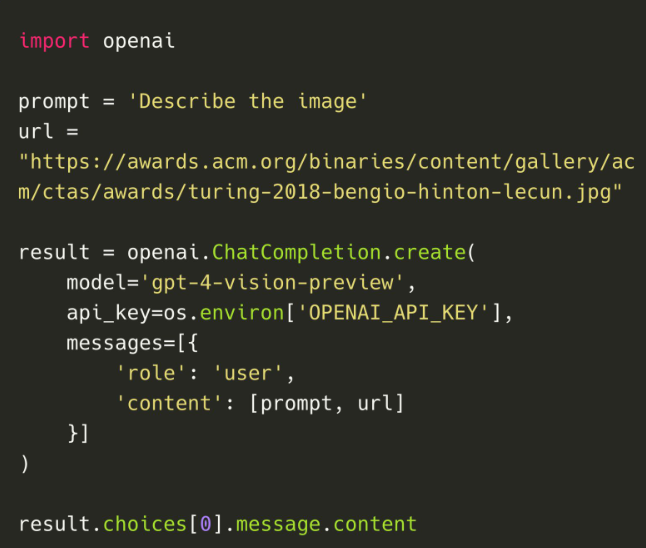

In [ ]:
tf.keras.preprocessing.image.load_img(os.path.join(images_path, 'gpt_4_vision.png'))

# Transformer vs BERT vs BART vs GPT

- BART = Bidirectional and Auto-Regressive Transformers

  - BART combines the bidirectional encoder of BERT with the auto-regressive decoder of GPT.
  
  - It has both masked language modeling and auto-regressive pre-training objectives.

---
---
---

1. **Transformer**:
   - **Architecture**: The Transformer is a neural network architecture introduced in the paper "Attention is All You Need" by Vaswani et al. It consists of encoder and decoder blocks, each containing self-attention mechanisms.
   - **Usage**: Transformers can be used for various sequence-to-sequence tasks, including machine translation, text summarization, and language modeling.
   - **Bidirectional**: Transformers are inherently bidirectional, meaning they can process input sequences in both directions simultaneously, capturing dependencies effectively.
   - **Examples**: Original Transformer model, OpenAI GPT models, BERT, T5, etc.

2. **BERT (Bidirectional Encoder Representations from Transformers)**:
   - **Architecture**: BERT is a variant of the Transformer architecture that is pre-trained using masked language modeling and next sentence prediction objectives.
   - **Pre-training**: BERT is pre-trained on large text corpora to learn deep contextual representations of words and sentences.
   - **Fine-tuning**: BERT can be fine-tuned on specific downstream tasks, such as text classification, named entity recognition, and question answering.
   - **Bidirectional Context**: BERT captures bidirectional context by masking certain words in the input sequence and predicting them based on the surrounding context.
   - **Examples**: BERT-base, BERT-large, etc.

3. **BART (Bidirectional and Auto-Regressive Transformers)**:
   - **Architecture**: BART combines the bidirectional encoder of BERT with the auto-regressive decoder of GPT. It is trained on denoising autoencoding and masked language modeling tasks.
   - **Pre-training**: BART is pre-trained on large text corpora using denoising autoencoding and masked language modeling objectives, similar to BERT.
   - **Fine-tuning**: BART can be fine-tuned for various text generation tasks, such as text summarization, language translation, and paraphrasing.
   - **Bidirectional and Autoregressive**: BART can both generate text autoregressively (like GPT) and encode bidirectional context (like BERT), making it versatile for both generation and understanding tasks.
   - **Examples**: BART-base, BART-large, etc.

4. **GPT (Generative Pre-trained Transformer)**:
   - **Architecture**: GPT models are based on the Transformer architecture, specifically the decoder part. They consist of multiple layers of self-attention and feedforward neural networks.
   - **Pre-training**: GPT models are pre-trained using unsupervised learning on large text corpora, with the objective of predicting the next word in a sequence given the previous context.
   - **Fine-tuning**: GPT models can be fine-tuned on specific downstream tasks such as text generation, summarization, and question answering.
   - **Autoregressive Generation**: GPT generates text autoregressively, meaning it predicts the next token based on the preceding tokens.
   - **Examples**: GPT-1, GPT-2, GPT-3, etc.

- Transformer is the base architecture that BERT, BART, and GPT are built upon, each with its own specific objectives, pre-training methods, and fine-tuning capabilities.

  - BERT focuses on bidirectional contextual representation learning,
  
  - BART combines bidirectional and autoregressive capabilities for text generation, and
  
  - GPT specializes in autoregressive text generation.  

# Text Classification

- Text classification is one of the most common tasks in NLP.

- It can be used for:

  - tagging customer feedback into categories,

  - routing support tickets according to their language,

  - filtering emails into spam,

  - sentiment analysis: a company like Tesla might analyze X (Twitter) posts to determine whether people like its new car roofs or not

  - etc.



- <font color="red">Now imagine that you need to build a system that can automatically identify emotional states such as "anger" or "joy" that people express about your company's product on X (Twitter). </font>

  - <font color="red">This can be used as part of a UI/UX initiative with an online experiment used to understand customer preferences to an existing product.</font>

- We will see how to use a model called DistilBERT to achieve this.

  - <a href="https://arxiv.org/abs/1910.01108">DistilBERT, a Distilled Version of BERT: Smaller, Faster, Cheaper and Lighter (2019)</a>
  
- The main advantage of this model is that it achieves comparable performance to BERT, while being significantly smaller and more efficient.

- This enables us to train a classifier in a few minutes, and if you want to train a larger BERT model you can simply change the <b>checkpoint of the pretrained model</b>.

  - A <b>checkpoint</b> corresponds to the set of weights that are loaded into a given transformer architecture.

- This will also be our first encounter with three of the core libraries from the Hugging Face ecosystem:

  - Datasets,
  
  - Tokenizers, and
  
  - Transformers.
  
- These libraries will allow us to quickly go from raw text to a fine-tuned model that can be used for inference on new tweets.

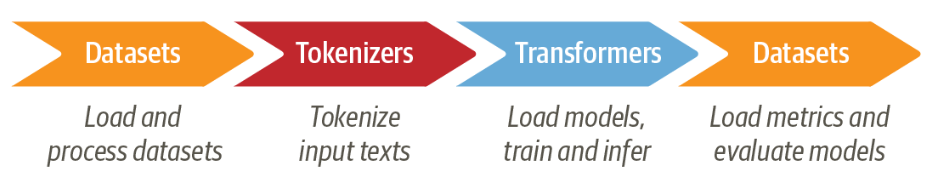

In [ ]:
tf.keras.preprocessing.image.load_img(os.path.join(images_path, 'hugging_face_pipeline.png'))

## The Dataset

- To build our emotion detector we'll use a dataset from an article that explored how emotions are represented in English Twitter messages.
  
  - <a href="http://dx.doi.org/10.18653/v1/D18-1404">CARER: Contextualized Affect Representations for Emotion Recognition (2018)</a>
  
- Unlike most sentiment analysis datasets that involve just "positive" and "negative" polarities, this dataset contains six basic emotions:

  - anger,
  
  - disgust,
  
  - fear,
  
  - joy,
  
  - sadness, and
  
  - surprise.
  
- Given a tweet, our task will be to train a model that can classify it into one of these emotions.

---
---
---

- We will download the data from the <a href="https://huggingface.co/datasets">Hugging Face Hub</a>.

- We can use the `list_datasets()` function to see what datasets are available on the Hub.

In [ ]:
! pip install datasets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.5/510.5 kB 6.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 11.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 15.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 9.4 MB/s eta 0:00:00


In [ ]:
# from datasets import list_datasets
import huggingface_hub

all_datasets = list(huggingface_hub.list_datasets())  #list_datasets()
print(f"There are {len(all_datasets)} datasets currently available on the Hub")
print(f"The first 10 are: {all_datasets[:10]}")

There are 133109 datasets currently available on the Hub
The first 10 are: [DatasetInfo(id='acronym_identification', author=None, sha='15ef643450d589d5883e289ffadeb03563e80a9e', created_at=datetime.datetime(2022, 3, 2, 23, 29, 22, tzinfo=datetime.timezone.utc), last_modified=datetime.datetime(2024, 1, 9, 11, 39, 57, tzinfo=datetime.timezone.utc), private=False, gated=False, disabled=False, downloads=962, likes=18, paperswithcode_id='acronym-identification', tags=['task_categories:token-classification', 'annotations_creators:expert-generated', 'language_creators:found', 'multilinguality:monolingual', 'size_categories:10K<n<100K', 'source_datasets:original', 'language:en', 'license:mit', 'acronym-identification', 'croissant', 'arxiv:2010.14678', 'region:us'], card_data=None, siblings=None), DatasetInfo(id='ade_corpus_v2', author=None, sha='4ba01c71687dd7c996597042449448ea312126cf', created_at=datetime.datetime(2022, 3, 2, 23, 29, 22, tzinfo=datetime.timezone.utc), last_modified=datetime.

- We see that each dataset is given a name, so let's load the `emotion` dataset with the `load_dataset()` function:

In [ ]:
# hide_output
from datasets import load_dataset

emotions = load_dataset("emotion") # trust_remote_code=True

/usr/local/lib/python3.10/dist-packages/datasets/load.py:1461: FutureWarning: The repository for emotion contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/emotion
You can avoid this message in future by passing the argument `trust_remote_code=True`.
Passing `trust_remote_code=True` will be mandatory to load this dataset from the next major release of `datasets`.
  warnings.warn(


Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

- If we look inside our `emotions` object we see it is similar to a Python dictionary, with each key corresponding to a different split.

- And we can use the usual dictionary syntax to access an individual split.

In [ ]:
emotions

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [ ]:
train_ds = emotions["train"]
train_ds

Dataset({
    features: ['text', 'label'],
    num_rows: 16000
})

- This returns an instance of the `Dataset` class.

- The `Dataset` object is one of the core data structures in <b>Datasets</b>

- For starters, it behaves like an ordinary Python array or list, so we can query its length, or access a single example by its index.

In [ ]:
len(train_ds)

16000

In [ ]:
train_ds[0]

{'text': 'i didnt feel humiliated', 'label': 0}

- We see that a single row is represented as a dictionary, where the keys correspond to the column names and the values are the tweet and the emotion.

- This reflects the fact that <b>Datasets</b> is based on [_Apache Arrow_](https://arrow.apache.org/), which defines a typed columnar format that is more memory efficient than native Python.

- We can see what data types are being used under the hood by accessing the `features` attribute of a `Dataset` object:

In [ ]:
train_ds.column_names

['text', 'label']

In [ ]:
print(train_ds.features)

{'text': Value(dtype='string', id=None), 'label': ClassLabel(names=['sadness', 'joy', 'love', 'anger', 'fear', 'surprise'], id=None)}


- In this case, the data type of the `text` column is `string`, while the `label` column is a special `ClassLabel` object that contains information about the class names and their mapping to integers.

- We can also access several rows with a slice.

In [ ]:
train_ds[:5]

{'text': ['i didnt feel humiliated',
  'i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake',
  'im grabbing a minute to post i feel greedy wrong',
  'i am ever feeling nostalgic about the fireplace i will know that it is still on the property',
  'i am feeling grouchy'],
 'label': [0, 0, 3, 2, 3]}

- In this case, the dictionary values are now lists instead of individual elements.

- We can also get the full column by name.

In [ ]:
train_ds["text"][:5]

['i didnt feel humiliated',
 'i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake',
 'im grabbing a minute to post i feel greedy wrong',
 'i am ever feeling nostalgic about the fireplace i will know that it is still on the property',
 'i am feeling grouchy']

- Now that we've seen how to load and inspect data with <b>Datasets</b>, let's do a few sanity checks about the content of our tweets.

$\rule{800pt}{10pt}$

- <font color="blue"><b> What if my dataset is not on the Hub?</b></font>

  - <font color="blue">We'll frequently be using the Hugging Face Hub to download datasets, but in many cases, you'll find yourself working with data that is either stored on your laptop or on a remote server in your organization.
  
  - In this event, <b>Datasets</b> provides several loading scripts to handle local and remote datasets. </font>

```asciidoc
|======
| Data format | Loading script | Example
| CSV | `csv` | `load_dataset("csv", data_files="my_file.csv")`
| Text | `text` | `load_dataset("text", data_files="my_file.txt")`
| JSON | `json` | `load_dataset("json", data_files="my_file.jsonl")`
|======
```

- <font color="blue">As you can see for each data format, we just need to pass the relevant loading script to the `load_dataset()` function, along with a `data_files` argument that specifies the path or URL to one or more files.

- For example, the source files for the `emotion` dataset are actually hosted on Dropbox, so an alternative way to load the dataset is to first download one of the splits.</font>

In [ ]:
#hide_output
# The original URL used in the book is no longer available, so we use a different one
# dataset_url = "https://huggingface.co/datasets/transformersbook/emotion-train-split/raw/main/train.txt"
# !wget {dataset_url}

In [ ]:
# !head -n 1 train.txt

- <font color="blue">We can see that here are no column headers and each tweet and emotion are separated by a semicolon.

- Nevertheless, this is quite similar to a CSV file, so we can load the dataset locally by using the `csv` script and pointing the `data_files` argument to the _train.txt_ file.</font>

In [ ]:
# #hide_output
# emotions_local = load_dataset("csv", data_files="train.txt", sep=";",
#                               names=["text", "label"])

- <font color="blue">Here we've also specified the type of delimiter and the names of the columns.

- An even simpler approach is to just point the `data_files` argument to the URL itself.</font>

In [ ]:
# #hide_output
# dataset_url = "https://huggingface.co/datasets/transformersbook/emotion-train-split/raw/main/train.txt"
# emotions_remote = load_dataset("csv", data_files=dataset_url, sep=";",
#                                names=["text", "label"])

- <font color="blue">This will automatically download and cache the dataset for you.

- <font color="blue">As you can see, the `load_dataset()` function is very versatile.

- <font color="blue">For more, see Datasets [documentation](https://huggingface.co/docs/datasets/loading.html).

$\rule{800pt}{10pt}$

### From Datasets to DataFrames

- Although <b>Datasets</b> provides a lot of low-level functionality to slice and dice our data, it is often convenient to convert a `Dataset` object to a Pandas `DataFrame` so we can access high-level APIs for data visualization.

- To enable the conversion, Datasets provides a `set_format()` method that allows us to change the _output format_ of the `Dataset`.

- Note that this does not change the underlying _data format_ (which is an Arrow table), and you can switch to another format later if needed:

In [ ]:
emotions["train"][:]

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3
...,...,...
15995,i just had a very brief time in the beanbag an...,0
15996,i am now turning and i feel pathetic that i am...,0
15997,i feel strong and good overall,1
15998,i feel like this was such a rude comment and i...,3


In [ ]:
emotions.set_format(type="pandas")
df = emotions["train"][:]

df

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3
...,...,...
15995,i just had a very brief time in the beanbag an...,0
15996,i am now turning and i feel pathetic that i am...,0
15997,i feel strong and good overall,1
15998,i feel like this was such a rude comment and i...,3


- The column headers have been preserved and the first few rows match our previous views of the data.

- However, the labels are represented as integers, so let's use the `int2str()` method of the `label` feature to create a new column in our `DataFrame` with the corresponding label names.

In [ ]:
def label_int2str(row):
    return emotions["train"].features["label"].int2str(row)

df["label_name"] = df["label"].apply(label_int2str)


df

,text,label,label_name
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger
...,...,...,...
15995,i just had a very brief time in the beanbag an...,0,sadness
15996,i am now turning and i feel pathetic that i am...,0,sadness
15997,i feel strong and good overall,1,joy
15998,i feel like this was such a rude comment and i...,3,anger


- Before diving into building a classifier, let's take a closer look at the dataset.

- As Andrej Karpathy notes in his famous blog post ["A Recipe for Training Neural Networks"](https://karpathy.github.io/2019/04/25/recipe), becoming "one with the data" is an essential step for training great models.

### Looking at the Class Distribution

Whenever you are working on text classification problems, it is a good idea to examine the distribution of examples across the classes. A dataset with a skewed class distribution might require a different treatment in terms of the training loss and evaluation metrics than a balanced one.

With Pandas and Matplotlib, we can quickly visualize the class distribution as follows:

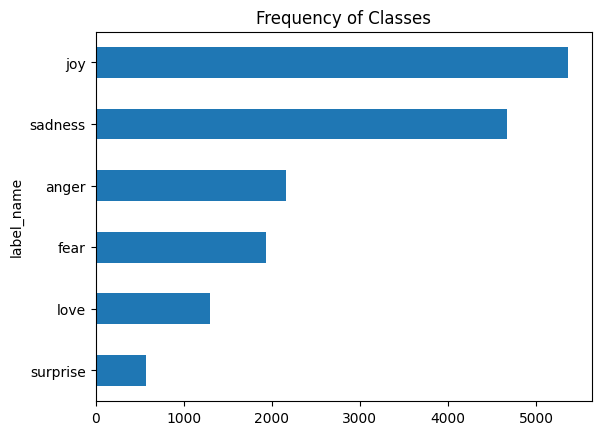

In [ ]:
import matplotlib.pyplot as plt

df["label_name"].value_counts(ascending=True).plot.barh()
plt.title("Frequency of Classes")
plt.show()

In this case, we can see that the dataset is heavily imbalanced; the `joy` and `sadness` classes appear frequently, whereas `love` and `surprise` are about 5–10 times rarer. There are several ways to deal with imbalanced data, including:

* Randomly oversample the minority class.
* Randomly undersample the majority class.
* Gather more labeled data from the underrepresented classes.

To keep things simple in this chapter, we'll work with the raw, unbalanced class frequencies. If you want to learn more about these sampling techniques, we recommend checking out the [Imbalanced-learn library](https://imbalanced-learn.org/stable/). Just make sure that you don't apply sampling methods _before_ creating your train/test splits, or you'll get plenty of leakage between them!

Now that we've looked at the classes, let's take a look at the tweets themselves.

### How Long Are Our Tweets?

Transformer models have a maximum input sequence length that is referred to as the _maximum context size_. For applications using DistilBERT, the maximum context size is 512 tokens, which amounts to a few paragraphs of text. As we'll see in the next section, a token is an atomic piece of text; for now, we'll treat a token as a single word. We can get a rough estimate of tweet lengths per emotion by looking at the distribution of words per tweet:

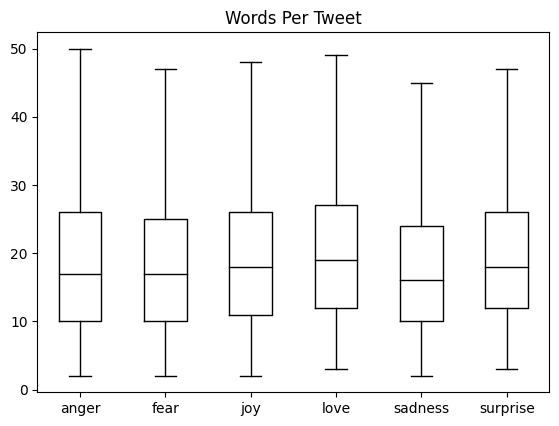

In [ ]:
df["Words Per Tweet"] = df["text"].str.split().apply(len)
df.boxplot("Words Per Tweet", by="label_name", grid=False, showfliers=False,
           color="black")
plt.suptitle("")
plt.xlabel("")
plt.show()

From the plot we see that for each emotion, most tweets are around 15 words long and the longest tweets are well below DistilBERT's maximum context size. Texts that are longer than a model's context size need to be truncated, which can lead to a loss in performance if the truncated text contains crucial information; in this case, it looks like that won't be an issue.

Let's now figure out how we can convert these raw texts into a format suitable for image:images/logo.png[hf,13,13] Transformers! While we're at it, let's also reset the output format of our dataset since we don't need the `DataFrame` format anymore:

In [ ]:
emotions.reset_format()

## From Text to Tokens

Transformer models like DistilBERT cannot receive raw strings as input; instead, they assume the text has been _tokenized_ and _encoded_ as numerical vectors. Tokenization is the step of breaking down a string into the atomic units used in the model. There are several tokenization strategies one can adopt, and the optimal splitting of words into subunits is usually learned from the corpus. Before looking at the tokenizer used for DistilBERT, let's consider two extreme cases: _character_ and _word_ tokenization.

### Character Tokenization

The simplest tokenization scheme is to feed each character individually to the model. In Python, `str` objects are really arrays under the hood, which allows us to quickly implement character-level tokenization with just one line of code:

In [ ]:
text = "Tokenizing text is a core task of NLP."
tokenized_text = list(text)
print(tokenized_text)

['T', 'o', 'k', 'e', 'n', 'i', 'z', 'i', 'n', 'g', ' ', 't', 'e', 'x', 't', ' ', 'i', 's', ' ', 'a', ' ', 'c', 'o', 'r', 'e', ' ', 't', 'a', 's', 'k', ' ', 'o', 'f', ' ', 'N', 'L', 'P', '.']


This is a good start, but we're not done yet. Our model expects each character to be  converted to an integer, a process sometimes called _numericalization_. One simple way to do this is by encoding each unique token (which are characters in this case) with a unique integer:

In [ ]:
token2idx = {ch: idx for idx, ch in enumerate(sorted(set(tokenized_text)))}
print(token2idx)

{' ': 0, '.': 1, 'L': 2, 'N': 3, 'P': 4, 'T': 5, 'a': 6, 'c': 7, 'e': 8, 'f': 9, 'g': 10, 'i': 11, 'k': 12, 'n': 13, 'o': 14, 'r': 15, 's': 16, 't': 17, 'x': 18, 'z': 19}


This gives us a mapping from each character in our vocabulary to a unique integer. We can now use `token2idx` to transform the tokenized text to a list of integers:

In [ ]:
input_ids = [token2idx[token] for token in tokenized_text]
print(input_ids)

[5, 14, 12, 8, 13, 11, 19, 11, 13, 10, 0, 17, 8, 18, 17, 0, 11, 16, 0, 6, 0, 7, 14, 15, 8, 0, 17, 6, 16, 12, 0, 14, 9, 0, 3, 2, 4, 1]


Each token has now been mapped to a unique numerical identifier (hence the name `input_ids`). The last step is to convert `input_ids` to a 2D tensor of one-hot vectors. One-hot vectors are frequently used in machine learning to encode categorical data, which can be either ordinal or nominal. For example, suppose we wanted to encode the names of characters in the _Transformers_ TV series. One way to do this would be to map each name to a unique ID, as follows:

In [ ]:
categorical_df = pd.DataFrame(
    {"Name": ["Bumblebee", "Optimus Prime", "Megatron"], "Label ID": [0,1,2]})
categorical_df

,Name,Label ID
0,Bumblebee,0
1,Optimus Prime,1
2,Megatron,2


The problem with this approach is that it creates a fictitious ordering between the names, and neural networks are _really_ good at learning these kinds of relationships. So instead, we can create a new column for each category and assign a 1 where the category is true, and a 0 otherwise. In Pandas, this can be implemented with the `get_dummies()` function as follows:

In [ ]:
pd.get_dummies(categorical_df["Name"])

,Bumblebee,Megatron,Optimus Prime
0,True,False,False
1,False,False,True
2,False,True,False


The rows of this `DataFrame` are the one-hot vectors, which have a single "hot" entry with a 1 and 0s everywhere else. Now, looking at our `input_ids`, we have a similar problem: the elements create an ordinal scale. This means that adding or subtracting two IDs is a meaningless operation, since the result is a new ID that represents another random token.

On the other hand, the result of adding two one-hot encodings can easily be interpreted: the two entries that are "hot" indicate that the corresponding tokens co-occur. We can create the one-hot encodings in PyTorch by converting `input_ids` to a tensor and applying the `one_hot()` function as follows:

In [ ]:
import torch
import torch.nn.functional as F

input_ids = torch.tensor(input_ids)
one_hot_encodings = F.one_hot(input_ids, num_classes=len(token2idx))
one_hot_encodings.shape

torch.Size([38, 20])

For each of the 38 input tokens we now have a one-hot vector with 20 dimensions, since our vocabulary consists of 20 unique characters.

> Warning: It's important to always set `num_classes` in the `one_hot()` function because otherwise the one-hot vectors may end up being shorter than the length of the vocabulary (and need to be padded with zeros manually). In TensorFlow, the equivalent function is `tf.one_hot()`, where the `depth` argument plays the role of `num_classes`.

By examining the first vector, we can verify that a 1 appears in the location indicated by `input_ids[0]`:

In [ ]:
print(f"Token: {tokenized_text[0]}")
print(f"Tensor index: {input_ids[0]}")
print(f"One-hot: {one_hot_encodings[0]}")

Token: T
Tensor index: 5
One-hot: tensor([0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])


From our simple example we can see that character-level tokenization ignores any structure in the text and treats the whole string as a stream of characters. Although this helps deal with misspellings and rare words, the main drawback is that linguistic structures such as words need to be _learned_ from the data. This requires significant compute, memory, and data. For this reason, character tokenization is rarely used in practice. Instead, some structure of the text is preserved during the tokenization step. _Word tokenization_ is a straightforward approach to achieve this, so let's take a look at how it works.

### Word Tokenization

Instead of splitting the text into characters, we can split it into words and map each word to an integer. Using words from the outset enables the model to skip the step of learning words from characters, and thereby reduces the complexity of the training process.

One simple class of word tokenizers uses whitespace to tokenize the text. We can do this by applying Python's `split()` function directly on the raw text (just like we did to measure the tweet lengths):

In [ ]:
tokenized_text = text.split()
print(tokenized_text)

['Tokenizing', 'text', 'is', 'a', 'core', 'task', 'of', 'NLP.']


From here we can take the same steps we took for the character tokenizer to map each word to an ID. However, we can already see one potential problem with this tokenization scheme: punctuation is not accounted for, so `NLP.` is treated as a single token. Given that words can include declinations, conjugations, or misspellings, the size of the vocabulary can easily grow into the millions!


> note: Some word tokenizers have extra rules for punctuation. One can also apply stemming or lemmatization, which normalizes words to their stem (e.g., "great", "greater", and "greatest" all become "great"), at the expense of losing some information in the text.

Having a large vocabulary is a problem because it requires neural networks to have an enormous number of parameters. To illustrate this, suppose we have 1 million unique words and want to compress the 1-million-dimensional input vectors to 1-thousand-dimensional vectors in the first layer of our neural network. This is a standard step in most NLP architectures, and the resulting weight matrix of this first layer would contain 1 million $\times$ 1 thousand = 1 billion weights. This is already comparable to the largest GPT-2 model,footnote:[GPT-2 is the successor of GPT, and it captivated the public's attention with its impressive ability to generate realistic text. We'll explore GPT-2 in detail in <<chapter_summarization>>.] which has around 1.5 billion parameters in total!

Naturally, we want to avoid being so wasteful with our model parameters since models are expensive to train, and larger models are more difficult to maintain. A common approach is to limit the vocabulary and discard rare words by considering, say, the 100,000 most common words in the corpus. Words that are not part of the vocabulary are classified as "unknown" and mapped to a shared `UNK` token. This means that we lose some potentially important information in the process of word tokenization, since the model has no information about words associated with `UNK`.

Wouldn't it be nice if there was a compromise between character and word tokenization that preserved all the input information _and_ some of the input structure? There is: _subword tokenization_.

### Subword Tokenization

The basic idea behind subword tokenization is to combine the best aspects of character and word tokenization. On the one hand, we want to split rare words into smaller units to allow the model to deal with complex words and misspellings. On the other hand, we want to keep frequent words as unique entities so that we can keep the length of our inputs to a manageable size. The main distinguishing feature of subword tokenization (as well as word tokenization) is that it is _learned_ from the pretraining corpus using a mix of statistical rules and algorithms.

There are several subword tokenization algorithms that are commonly used in NLP, but let's start with WordPiece,footnote:[M. Schuster and K. Nakajima, "Japanese and Korean Voice Search," _2012 IEEE International Conference on Acoustics, Speech and Signal Processing_ (2012): 5149–5152, https://doi.org/10.1109/ICASSP.2012.6289079.] which is used by the BERT and DistilBERT tokenizers. The easiest way to understand how WordPiece works is to see it in action. image:images/logo.png[hf,13,13] Transformers provides a convenient `AutoTokenizer` class that allows you to quickly load the tokenizer associated with a pretrained model—we just call its `from_pretrained()` method, providing the ID of a model on the Hub or a local file path. Let's start by loading the tokenizer for DistilBERT:

In [ ]:
# hide_output
from transformers import AutoTokenizer

model_ckpt = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

The `AutoTokenizer` class belongs to a larger set of ["auto" classes](https://huggingface.co/docs/transformers/model_doc/auto) whose job is to automatically retrieve the model's configuration, pretrained weights, or vocabulary from the name of the checkpoint. This allows you to quickly switch between models, but if you wish to load the specific class manually you can do so as well. For example, we could have loaded the DistilBERT tokenizer as follows:

```python
from transformers import DistilBertTokenizer

distilbert_tokenizer = DistilBertTokenizer.from_pretrained(model_ckpt)
```

> note: When you run the `AutoTokenizer.from_pretrained()` method for the first time you will see a progress bar that shows which parameters of the pretrained tokenizer are loaded from the Hugging Face Hub. When you run the code a second time, it will load the tokenizer from the cache, usually located at _~/.cache/huggingface/_.

Let's examine how this tokenizer works by feeding it our simple "Tokenizing text is a core task of NLP." example text:

In [ ]:
encoded_text = tokenizer(text)
print(encoded_text)

{'input_ids': [101, 19204, 6026, 3793, 2003, 1037, 4563, 4708, 1997, 17953, 2361, 1012, 102], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}


Just like we saw with character tokenization, we can see that the words have been mapped to unique integers in the `input_ids` field. We'll discuss the role of the `attention_mask` field in the next section. Now that we have the `input_ids`, we can convert them back into tokens by using the tokenizer's `convert_ids_to_tokens()` method:

In [ ]:
tokens = tokenizer.convert_ids_to_tokens(encoded_text.input_ids)
print(tokens)

['[CLS]', 'token', '##izing', 'text', 'is', 'a', 'core', 'task', 'of', 'nl', '##p', '.', '[SEP]']


We can observe three things here. First, some special `[CLS]` and `[SEP]` tokens have been added to the start and end of the sequence. These tokens differ from model to model, but their main role is to indicate the start and end of a sequence. Second, the tokens have each been lowercased, which is a feature of this particular checkpoint. Finally, we can see that "tokenizing" and "NLP" have been split into two tokens, which makes sense since they are not common words. The `##` prefix in `##izing` and `##p` means that the preceding string is not whitespace; any token with this prefix should be merged with the previous token when you convert the tokens back to a string. The `AutoTokenizer` class has a `convert_tokens_to_string()` method for doing just that, so let's apply it to our tokens:

In [ ]:
print(tokenizer.convert_tokens_to_string(tokens))

[CLS] tokenizing text is a core task of nlp. [SEP]


The `AutoTokenizer` class also has several attributes that provide information about the tokenizer. For example, we can inspect the vocabulary size:

In [ ]:
tokenizer.vocab_size

30522

and the corresponding model's maximum context size:

In [ ]:
tokenizer.model_max_length

512

Another interesting attribute to know about is the names of the fields that the model expects in its forward pass:

In [ ]:
tokenizer.model_input_names

['input_ids', 'attention_mask']

Now that we have a basic understanding of the tokenization process for a single string, let's see how we can tokenize the whole dataset!

> warning: When using pretrained models, it is _really_ important to make sure that you use the same tokenizer that the model was trained with. From the model's perspective, switching the tokenizer is like shuffling the vocabulary. If everyone around you started swapping random words like "house" for "cat," you'd have a hard time understanding what was going on too!

### Tokenizing the Whole Dataset

To tokenize the whole corpus, we'll use the `map()` method of our `DatasetDict` object. We'll encounter this method many times throughout this book, as it provides a convenient way to apply a processing function to each element in a dataset. As we'll soon see, the `map()` method can also be used to create new rows and columns.

To get started, the first thing we need is a processing function to tokenize our examples with:

In [ ]:
def tokenize(batch):
    return tokenizer(batch["text"], padding=True, truncation=True)

This function applies the tokenizer to a batch of examples; `padding=True` will pad the examples with zeros to the size of the longest one in a batch, and `truncation=True` will truncate the examples to the model's maximum context size. To see `tokenize()` in action, let's pass a batch of two examples from the training set:

In [ ]:
print(tokenize(emotions["train"][:2]))

{'input_ids': [[101, 1045, 2134, 2102, 2514, 26608, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [101, 1045, 2064, 2175, 2013, 3110, 2061, 20625, 2000, 2061, 9636, 17772, 2074, 2013, 2108, 2105, 2619, 2040, 14977, 1998, 2003, 8300, 102]], 'attention_mask': [[1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]}


Here we can see the result of padding: the first element of `input_ids` is shorter than the second, so zeros have been added to that element to make them the same length. These zeros have a corresponding `[PAD]` token in the vocabulary, and the set of special tokens also includes the `[CLS]` and `[SEP]` tokens that we encountered earlier:

In [ ]:
#hide_input
tokens2ids = list(zip(tokenizer.all_special_tokens, tokenizer.all_special_ids))
data = sorted(tokens2ids, key=lambda x : x[-1])
df = pd.DataFrame(data, columns=["Special Token", "Special Token ID"])
df.T

,0,1,2,3,4
Special Token,[PAD],[UNK],[CLS],[SEP],[MASK]
Special Token ID,0,100,101,102,103


Also note that in addition to returning the encoded tweets as `input_ids`, the tokenizer returns a list of `attention_mask` arrays. This is because we do not want the model to get confused by the additional padding tokens: the attention mask allows the model to ignore the padded parts of the input. <<attention-mask>> provides a visual explanation of how the input IDs and attention masks are padded.

<img alt="attention-mask" caption="For each batch, the input sequences are padded to the maximum sequence length in the batch; the attention mask is used in the model to ignore the padded areas of the input tensors" src="images/chapter02_attention-mask.png" id="attention-mask"/>

In [ ]:
tf.keras.preprocessing.image.load_img(os.path.join(images_path, 'tokenization_and_attention_masks.png'))

Once we've defined a processing function, we can apply it across all the splits in the corpus in a single line of code:

In [ ]:
%%time
# hide_output
emotions_encoded = emotions.map(tokenize, batched=True, batch_size=None)

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

By default, the `map()` method operates individually on every example in the corpus, so setting `batched=True` will encode the tweets in batches. Because we've set `batch_size=None`, our `tokenize()` function will be applied on the full dataset as a single batch. This ensures that the input tensors and attention masks have the same shape globally, and we can see that this operation has added new `input_ids` and `attention_mask` columns to the dataset:

In [ ]:
print(emotions_encoded["train"].column_names)

['text', 'label', 'input_ids', 'attention_mask']


> Note: In later chapters, we'll see how _data collators_ can be used to dynamically pad the tensors in each batch. Padding globally will come in handy in the next section, where we extract a feature matrix from the whole corpus.

## Training a Text Classifier

As discussed in <<chapter_introduction>>, models like DistilBERT are pretrained to predict masked words in a sequence of text. However, we can't use these language models directly for text classification; we need to modify them slightly. To understand what modifications are necessary, let's take a look at the architecture of an encoder-based model like DistilBERT, which is depicted in <<encoder-classifier>>.

<img alt="encoder-classifier" caption="The architecture used for sequence classification with an encoder-based transformer; it consists of the model's pretrained body (blue) combined with a custom classification head (orange)" src="images/chapter02_encoder-classifier.png" id="encoder-classifier"/>

In [ ]:
tf.keras.preprocessing.image.load_img(os.path.join(images_path, 'encoder_only_based_models_like_DistilBERT.png'))

First, the text is tokenized and represented as one-hot vectors called _token encodings_. The size of the tokenizer vocabulary determines the dimension of the token encodings, and it usually consists of 20k–200k unique tokens. Next, these token encodings are converted to _token embeddings_, which are vectors living in a lower-dimensional space. The token embeddings are then passed through the encoder block layers to yield a _hidden state_ for each input token. For the pretraining objective of language modeling,&#x2060;footnote:[In the case of DistilBERT, it's guessing the masked tokens.] each hidden state is fed to a layer that predicts the masked input tokens. For the classification task, we replace the language modeling layer with a classification layer.

> note: In practice, PyTorch skips the step of creating one-hot vectors for token encodings because multiplying a matrix with a one-hot vector is the same as selecting a column from the matrix. This can be done directly by getting the column with the token ID from the matrix. We'll see this in <<chapter_anatomy>> when we use the `nn.Embedding` class.

We have two options to train such a model on our Twitter dataset:

- _Feature extraction_:: We use the hidden states as features and just train a classifier on them, without modifying the pretrained model.
- _Fine-tuning_:: We train the whole model end-to-end, which also updates the parameters of the pretrained model.

In the following sections we explore both options for DistilBERT and examine their trade-offs.

### Transformers as Feature Extractors


Using a transformer as a feature extractor is fairly simple. As shown in <<encoder-features>>, we freeze the body's weights during training and use the hidden states as features for the classifier. The advantage of this approach is that we can quickly train a small or shallow model. Such a model could be a neural classification layer or a method that does not rely on gradients, such as a random forest. This method is especially convenient if GPUs are unavailable, since the hidden states only need to be precomputed once.

<img alt="encoder-features" caption="In the feature-based approach, the DistilBERT model is frozen and just provides features for a classifier" src="images/chapter02_encoder-feature-based.png" id="encoder-features"/>

In [ ]:
tf.keras.preprocessing.image.load_img(os.path.join(images_path, 'DistilBERT_as_feature_extractors.png'))

#### Using pretrained models


We will use another convenient auto class from image:images/logo.png[hf,13,13] Transformers called `AutoModel`. Similar to the `AutoTokenizer` class, `AutoModel` has a `from_pretrained()` method to load the weights of a pretrained model. Let's use this method to load the DistilBERT checkpoint:

In [ ]:
# hide_output
from transformers import AutoModel

model_ckpt = "distilbert-base-uncased"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AutoModel.from_pretrained(model_ckpt).to(device)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Here we've used PyTorch to check whether a GPU is available or not, and then chained the PyTorch `nn.Module.to()` method to the model loader. This ensures that the model will run on the GPU if we have one. If not, the model will run on the CPU, which can be considerably slower.

The `AutoModel` class converts the token encodings to embeddings, and then feeds them through the encoder stack to return the hidden states. Let's take a look at how we can extract these states from our corpus.

$\rule{800pt}{10pt}$

- <font color="red">Interoperability Between Frameworks:</font>

  - <font color="red">Although most of the code on Hugging Face is designed for interoperability with PyTorch, <b>Transformers</b> library provides tight interoperability with TensorFlow and JAX.
  
  - <font color="red">This means that you only need to change a few lines of code to load a pretrained model in your favorite deep learning framework.</font>
  
  - <font color="red">For example, we can load DistilBERT in TensorFlow by using the `TFAutoModel` class as follows:</font>

In [ ]:
#hide_output
from transformers import TFAutoModel

tf_model = TFAutoModel.from_pretrained(model_ckpt)

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertModel: ['vocab_projector.bias', 'vocab_transform.bias', 'vocab_layer_norm.bias', 'vocab_transform.weight', 'vocab_layer_norm.weight']
- This IS expected if you are initializing TFDistilBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFDistilBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFDistilBertModel for predictions without further training.


- <font color="red">This interoperability is especially useful when a model is only released in one framework, but you'd like to use it in another.

- <font color="red">For example, the [XLM-RoBERTa model](https://huggingface.co/xlm-roberta-base) only has PyTorch weights, so if you try to load it in TensorFlow as we did before, you'll get an error:

```python
tf_xlmr = TFAutoModel.from_pretrained("xlm-roberta-base")
```

- <font color="red">In these cases, you can specify a `from_pt=True` argument to the `TfAutoModel.from_pretrained()` function, and the library will automatically download and convert the PyTorch weights for you.

In [ ]:
tf_xlmr = TFAutoModel.from_pretrained("xlm-roberta-base", from_pt=True)

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFXLMRobertaModel: ['lm_head.layer_norm.bias', 'lm_head.bias', 'lm_head.dense.bias', 'lm_head.dense.weight', 'lm_head.layer_norm.weight', 'lm_head.decoder.weight']
- This IS expected if you are initializing TFXLMRobertaModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFXLMRobertaModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFXLMRobertaModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFXLMRobertaModel for predictions without further training.


- <font color="red">It is very simple to switch between frameworks in Transformers.

- <font color="red">In most cases, you can just add a "TF" prefix to the classes and you'll get the equivalent TensorFlow 2.0 classes.

- <font color="red">When we use the `"pt"` string (e.g., in the following section), which is short for PyTorch, just replace it with "`tf"`, which is short for TensorFlow.

$\rule{800pt}{10pt}$

#### Extracting the last hidden states

To warm up, let's retrieve the last hidden states for a single string. The first thing we need to do is encode the string and convert the tokens to PyTorch tensors. This can be done by providing the `return_tensors="pt"` argument to the tokenizer as follows:

In [ ]:
text = "this is a test"
inputs = tokenizer(text, return_tensors="pt")
print(f"Input tensor shape: {inputs['input_ids'].size()}")

Input tensor shape: torch.Size([1, 6])


As we can see, the resulting tensor has the shape `[batch_size, n_tokens]`. Now that we have the encodings as a tensor, the final step is to place them on the same device as the model and pass the inputs as follows:

In [ ]:
inputs = {k:v.to(device) for k,v in inputs.items()}
with torch.no_grad():
    outputs = model(**inputs)
print(outputs)

BaseModelOutput(last_hidden_state=tensor([[[-0.1565, -0.1862,  0.0528,  ..., -0.1188,  0.0662,  0.5470],
         [-0.3575, -0.6484, -0.0618,  ..., -0.3040,  0.3508,  0.5221],
         [-0.2772, -0.4459,  0.1818,  ..., -0.0948, -0.0076,  0.9958],
         [-0.2841, -0.3917,  0.3753,  ..., -0.2151, -0.1173,  1.0526],
         [ 0.2661, -0.5094, -0.3180,  ..., -0.4203,  0.0144, -0.2149],
         [ 0.9441,  0.0112, -0.4714,  ...,  0.1439, -0.7288, -0.1619]]]), hidden_states=None, attentions=None)


Here we've used the `torch.no_grad()` context manager to disable the automatic calculation of the gradient. This is useful for inference since it reduces the memory footprint of the computations. Depending on the model configuration, the output can contain several objects, such as the hidden states, losses, or attentions, arranged in a class similar to a `namedtuple` in Python. In our example, the model output is an instance of `BaseModelOutput`, and we can simply access its attributes by name. The current model returns only one attribute, which is the last hidden state, so let's examine its shape:

In [ ]:
outputs.last_hidden_state.size()

torch.Size([1, 6, 768])

Looking at the hidden state tensor, we see that it has the shape `[batch_size, n_tokens, hidden_dim]`. In other words, a 768-dimensional vector is returned for each of the 6 input tokens. For classification tasks, it is common practice to just use the hidden state associated with the `[CLS]` token as the input feature. Since this token appears at the start of each sequence, we can extract it by simply indexing into `outputs.last_hidden_state` as follows:

In [ ]:
outputs.last_hidden_state[:,0].size()

torch.Size([1, 768])

Now that we know how to get the last hidden state for a single string, let's do the same thing for the whole dataset by creating a new `hidden_state` column that stores all these vectors. As we did with the tokenizer, we'll use the `map()` method of `DatasetDict` to extract all the hidden states in one go. The first thing we need to do is wrap the previous steps in a processing function:

In [ ]:
def extract_hidden_states(batch):
    # Place model inputs on the GPU
    inputs = {k:v.to(device) for k,v in batch.items()
              if k in tokenizer.model_input_names}
    # Extract last hidden states
    with torch.no_grad():
        last_hidden_state = model(**inputs).last_hidden_state
    # Return vector for [CLS] token
    return {"hidden_state": last_hidden_state[:,0].cpu().numpy()}

The only difference between this function and our previous logic is the final step where we place the final hidden state back on the CPU as a NumPy array. The `map()` method requires the processing function to return Python or NumPy objects when we're using batched inputs.

Since our model expects tensors as inputs, the next thing to do is convert the `input_ids` and `attention_mask` columns to the `"torch"` format, as follows:

In [ ]:
emotions_encoded.set_format("torch",
                            columns=["input_ids", "attention_mask", "label"])

We can then go ahead and extract the hidden states across all splits in one go:

In [ ]:
#hide_output
emotions_hidden = emotions_encoded.map(extract_hidden_states, batched=True)

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Note that we did not set `batch_size=None` in this case, so the default `batch_size=1000` is used instead. As expected, applying the +extract_&#x200b;hid&#x2060;den_&#x200b;states()+ function has added a new `hidden_state` column to our dataset:

In [ ]:
emotions_hidden["train"].column_names

Now that we have the hidden states associated with each tweet, the next step is to train a classifier on them. To do that, we'll need a feature matrix - let's take a look.

#### Creating a feature matrix

The preprocessed dataset now contains all the information we need to train a classifier on it. We will use the hidden states as input features and the labels as targets. We can easily create the corresponding arrays in the well-known Scikit-Learn format as follows:

In [ ]:
import numpy as np

X_train = np.array(emotions_hidden["train"]["hidden_state"])
X_valid = np.array(emotions_hidden["validation"]["hidden_state"])
y_train = np.array(emotions_hidden["train"]["label"])
y_valid = np.array(emotions_hidden["validation"]["label"])
X_train.shape, X_valid.shape

Before we train a model on the hidden states, it's good practice to perform a sanity check to ensure that they provide a useful representation of the emotions we want to classify. In the next section, we'll see how visualizing the features provides a fast way to achieve this.

#### Visualizing the training set

Since visualizing the hidden states in 768 dimensions is tricky to say the least, we'll use the powerful UMAPfootnote:[L. McInnes, J. Healy, and J. Melville, ["UMAP: Uniform Manifold Approximation and Projection for Dimension Reduction"](https://arxiv.org/abs/1802.03426), (2018).] algorithm to project the vectors down to 2D.  Since UMAP works best when the features are scaled to lie in the [0,1] interval, we'll first apply a `MinMaxScaler` and then use the UMAP implementation from the `umap-learn` library to reduce the hidden states:

In [ ]:
from umap import UMAP
from sklearn.preprocessing import MinMaxScaler

# Scale features to [0,1] range
X_scaled = MinMaxScaler().fit_transform(X_train)
# Initialize and fit UMAP
mapper = UMAP(n_components=2, metric="cosine").fit(X_scaled)
# Create a DataFrame of 2D embeddings
df_emb = pd.DataFrame(mapper.embedding_, columns=["X", "Y"])
df_emb["label"] = y_train
df_emb.head()

The result is an array with the same number of training samples, but with only 2 features instead of the 768 we started with! Let's investigate the compressed data a little bit further and plot the density of points for each category separately:

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(7,5))
axes = axes.flatten()
cmaps = ["Greys", "Blues", "Oranges", "Reds", "Purples", "Greens"]
labels = emotions["train"].features["label"].names

for i, (label, cmap) in enumerate(zip(labels, cmaps)):
    df_emb_sub = df_emb.query(f"label == {i}")
    axes[i].hexbin(df_emb_sub["X"], df_emb_sub["Y"], cmap=cmap,
                   gridsize=20, linewidths=(0,))
    axes[i].set_title(label)
    axes[i].set_xticks([]), axes[i].set_yticks([])

plt.tight_layout()
plt.show()


>note: These are only projections onto a lower-dimensional space. Just because some categories overlap does not mean that they are not separable in the original space. Conversely, if they are separable in the projected space they will be separable in the original space.

From this plot we can see some clear patterns: the negative feelings such as `sadness`, `anger`, and `fear` all occupy similar regions with slightly varying distributions. On the other hand, `joy` and `love` are well separated from the negative emotions and also share a similar space. Finally, `surprise` is scattered all over the place. Although we may have hoped for some separation, this is in no way guaranteed since the model was not trained to know the difference between these emotions. It only learned them implicitly by guessing the masked words in texts.

Now that we've gained some insight into the features of our dataset, let's finally train a model on it!

#### Training a simple classifier


We've seen that the hidden states are somewhat different between the emotions, although for several of them there is no obvious boundary. Let's use these hidden states to train a logistic regression model with Scikit-Learn. Training such a simple model is fast and does not require a GPU:

In [ ]:
#hide_output
# We increase `max_iter` to guarantee convergence
from sklearn.linear_model import LogisticRegression

lr_clf = LogisticRegression(max_iter=3000)
lr_clf.fit(X_train, y_train)

In [ ]:
lr_clf.score(X_valid, y_valid)

Looking at the accuracy, it might appear that our model is just a bit better than random—but since we are dealing with an unbalanced multiclass dataset, it's actually significantly better. We can examine whether our model is any good by comparing it against a simple baseline. In Scikit-Learn there is a `DummyClassifier` that can be used to build a classifier with simple heuristics such as always choosing the majority class or always drawing a random class. In this case the best-performing heuristic is to always choose the most frequent class, which yields an accuracy of about 35%:

In [ ]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_clf.fit(X_train, y_train)
dummy_clf.score(X_valid, y_valid)

So, our simple classifier with DistilBERT embeddings is significantly better than our baseline. We can further investigate the performance of the model by looking at the confusion matrix of the classifier, which tells us the relationship between the true and predicted labels:

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

def plot_confusion_matrix(y_preds, y_true, labels):
    cm = confusion_matrix(y_true, y_preds, normalize="true")
    fig, ax = plt.subplots(figsize=(6, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap="Blues", values_format=".2f", ax=ax, colorbar=False)
    plt.title("Normalized confusion matrix")
    plt.show()

y_preds = lr_clf.predict(X_valid)
plot_confusion_matrix(y_preds, y_valid, labels)

We can see that `anger` and `fear` are most often confused with `sadness`, which agrees with the observation we made when visualizing the embeddings. Also, `love` and `surprise` are frequently mistaken for `joy`.

In the next section we will explore the fine-tuning approach, which leads to superior classification performance. It is, however, important to note that doing this requires more computational resources, such as GPUs, that might not be available in your organization. In cases like these, a feature-based approach can be a good compromise between doing traditional machine learning and deep learning.

### Fine-Tuning Transformers


Let's now explore what it takes to fine-tune a transformer end-to-end. With the fine-tuning approach we do not use the hidden states as fixed features, but instead train them as shown in <<encoder-tuning>>. This requires the classification head to be differentiable, which is why this method usually uses a neural network for classification.

<img alt="encoder-tuning" caption="When using the fine-tuning approach the whole DistilBERT model is trained along with the classification head" src="images/chapter02_encoder-fine-tuning.png" id="encoder-tuning"/>

In [ ]:
tf.keras.preprocessing.image.load_img(os.path.join(images_path, 'fine_tuning_DistilBERT.png'))

Training the hidden states that serve as inputs to the classification model will help us avoid the problem of working with data that may not be well suited for the classification task. Instead, the initial hidden states adapt during training to decrease the model loss and thus increase its performance.

We'll be using the `Trainer` API from image:images/logo.png[hf,13,13] Transformers to simplify the training loop. Let's look at the ingredients we need to set one up!

#### Loading a pretrained model

The first thing we need is a pretrained DistilBERT model like the one we used in the feature-based approach. The only slight modification is that we use the `AutoModelForSequenceClassification` model instead of `AutoModel`. The difference is that the `AutoModelForSequenceClassification` model has a classification head on top of the pretrained model outputs, which can be easily trained with the base model. We just need to specify how many labels the model has to predict (six in our case), since this dictates the number of outputs the classification head has:

In [ ]:
# hide_output
from transformers import AutoModelForSequenceClassification

num_labels = 6
model = (AutoModelForSequenceClassification
         .from_pretrained(model_ckpt, num_labels=num_labels)
         .to(device))

You will see a warning that some parts of the model are randomly initialized. This is normal since the classification head has not yet been trained. The next step is to define the metrics that we'll use to evaluate our model's performance during fine-tuning.

#### Defining the performance metrics


To monitor metrics during training, we need to define a `compute_metrics()` function for the `Trainer`.  This function receives an `EvalPrediction` object (which is a named tuple with `predictions` and `label_ids` attributes) and needs to return a dictionary that maps each metric's name to its value. For our application, we'll compute the $F_1$-score and the accuracy of the model as follows:

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    f1 = f1_score(labels, preds, average="weighted")
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "f1": f1}

With the dataset and metrics ready, we just have two final things to take care of before we define the `Trainer` class:

1. Log in to our account on the Hugging Face Hub. This will allow us to push our fine-tuned model to our account on the Hub and share it with the community.
2. Define all the hyperparameters for the training run.

We'll tackle these steps in the next section.

#### Training the model

If you're running this code in a Jupyter notebook, you can log in to the Hub with the following helper function:

In [ ]:
from huggingface_hub import notebook_login

notebook_login()

This will display a widget in which you can enter your username and password, or an access token with write privileges. You can find details on how to create access tokens in the [Hub documentation](https://huggingface.co/docs/hub/security#user-access-tokens). If you're working in the terminal, you can log in by running the following command:

```bash
$ huggingface-cli login
```

To define the training parameters, we use the `TrainingArguments` class. This class stores a lot of information and gives you fine-grained control over the training and evaluation. The most important argument to specify is `output_dir`, which is where all the artifacts from training are stored. Here is an example of `TrainingArguments` in all its glory:

In [ ]:
from transformers import Trainer, TrainingArguments

batch_size = 64
logging_steps = len(emotions_encoded["train"]) // batch_size
model_name = f"{model_ckpt}-finetuned-emotion"
training_args = TrainingArguments(output_dir=model_name,
                                  num_train_epochs=2,
                                  learning_rate=2e-5,
                                  per_device_train_batch_size=batch_size,
                                  per_device_eval_batch_size=batch_size,
                                  weight_decay=0.01,
                                  evaluation_strategy="epoch",
                                  disable_tqdm=False,
                                  logging_steps=logging_steps,
                                  push_to_hub=True,
                                  log_level="error")

Here we also set the batch size, learning rate, and number of epochs, and specify to load the best model at the end of the training run. With this final ingredient, we can instantiate and fine-tune our model with the `Trainer`:

In [ ]:
from transformers import Trainer

trainer = Trainer(model=model, args=training_args,
                  compute_metrics=compute_metrics,
                  train_dataset=emotions_encoded["train"],
                  eval_dataset=emotions_encoded["validation"],
                  tokenizer=tokenizer)
trainer.train();

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.840900,0.327445,0.896500,0.892285
2,0.255000,0.220472,0.922500,0.922550


Looking at the logs, we can see that our model has an $F_1$-score on the validation set of around 92% - this is a significant improvement over the feature-based approach!

We can take a more detailed look at the training metrics by calculating the confusion matrix. To visualize the confusion matrix, we first need to get the predictions on the validation set. The `predict()` method of the `Trainer` class returns several useful objects we can use for evaluation:

In [ ]:
# hide_output
preds_output = trainer.predict(emotions_encoded["validation"])

The output of the `predict()` method is a `PredictionOutput` object that contains arrays of `predictions` and `label_ids`, along with the metrics we passed to the trainer. For example, the metrics on the validation set can be accessed as follows:

In [ ]:
preds_output.metrics

{'test_loss': 0.22047173976898193,
 'test_accuracy': 0.9225,
 'test_f1': 0.9225500751072866,
 'test_runtime': 1.6357,
 'test_samples_per_second': 1222.725,
 'test_steps_per_second': 19.564}

It also contains the raw predictions for each class. We can decode the predictions greedily using `np.argmax()`. This yields the predicted labels and has the same format as the labels returned by the Scikit-Learn models in the feature-based approach:

In [ ]:
y_preds = np.argmax(preds_output.predictions, axis=1)

With the predictions, we can plot the confusion matrix again:

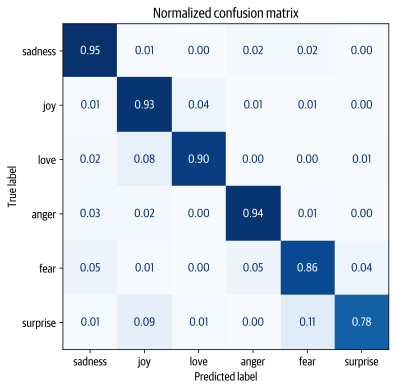

In [ ]:
plot_confusion_matrix(y_preds, y_valid, labels)

This is much closer to the ideal diagonal confusion matrix.  The `love` category is still often confused with `joy`, which seems natural. `surprise` is also frequently mistaken for `joy`, or confused with `fear`. Overall the performance of the model seems quite good, but before we call it a day, let's dive a little deeper into the types of errors our model is likely to make.

$\rule{800pt}{10pt}$

- <font color="red"> Fine-Tuning with Keras

- <font color="red"> For use with TensorFlow, it's possible to fine-tune your models with the Keras API.

- <font color="red"> The main difference from the PyTorch API is that there is no `Trainer` class, since Keras models already provide a built-in `fit()` method.

- <font color="red"> To see how this works, let's first load  DistilBERT as a TensorFlow model.

In [ ]:
#hide_output
from transformers import TFAutoModelForSequenceClassification

tf_model = (TFAutoModelForSequenceClassification
            .from_pretrained(model_ckpt, num_labels=num_labels))

2021-10-29 15:33:36.938811: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudnn.so.8'; dlerror: libcudnn.so.8: cannot open shared object file: No such file or directory
2021-10-29 15:33:36.938844: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1835] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
2021-10-29 15:33:36.939933: I tensorflow/core/platform/cpu_feature_guard.cc:142] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2021-10-29 15:33:36.962642: W tens

- <font color="red"> Next, we'll convert our datasets into the `tf.data.Dataset` format.

- <font color="red"> Since we have already padded our tokenized inputs, we can do this easily by applying the `to_tf_dataset()` method to `emotions_encoded`.

In [ ]:
# The column names to convert to TensorFlow tensors
tokenizer_columns = tokenizer.model_input_names

tf_train_dataset = emotions_encoded["train"].to_tf_dataset(
    columns=tokenizer_columns, label_cols=["label"], shuffle=True,
    batch_size=batch_size)
tf_eval_dataset = emotions_encoded["validation"].to_tf_dataset(
    columns=tokenizer_columns, label_cols=["label"], shuffle=False,
    batch_size=batch_size)

- <font color="red">we've also shuffled the training set, and defined the batch size for it and the validation set.

- <font color="red"> The last thing to do is compile and train the model.

In [ ]:
#hide_output
import tensorflow as tf

tf_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=tf.metrics.SparseCategoricalAccuracy())

tf_model.fit(tf_train_dataset, validation_data=tf_eval_dataset, epochs=2)

2021-10-29 15:36:00.548707: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:185] None of the MLIR Optimization Passes are enabled (registered 2)


Epoch 1/2
250/250 [==============================] - 478s 2s/step - loss: 0.5379 - sparse_categorical_accuracy: 0.8138 - val_loss: 0.1452 - val_sparse_categorical_accuracy: 0.9430
Epoch 2/2
250/250 [==============================] - 471s 2s/step - loss: 0.1424 - sparse_categorical_accuracy: 0.9415 - val_loss: 0.1512 - val_sparse_categorical_accuracy: 0.9335


<keras.callbacks.History>

$\rule{800pt}{10pt}$

#### Error analysis

- Before moving on, we should investigate our model's predictions a little bit further.

- A simple yet powerful technique is to sort the validation samples by the model loss.

- When we pass the label during the forward pass, the loss is automatically calculated and returned.

- Here's a function that returns the loss along with the predicted label:

In [ ]:
from torch.nn.functional import cross_entropy

def forward_pass_with_label(batch):
    # Place all input tensors on the same device as the model
    inputs = {k:v.to(device) for k,v in batch.items()
              if k in tokenizer.model_input_names}

    with torch.no_grad():
        output = model(**inputs)
        pred_label = torch.argmax(output.logits, axis=-1)
        loss = cross_entropy(output.logits, batch["label"].to(device),
                             reduction="none")

    # Place outputs on CPU for compatibility with other dataset columns
    return {"loss": loss.cpu().numpy(),
            "predicted_label": pred_label.cpu().numpy()}

Using the `map()` method once more, we can apply this function to get the losses for all the samples:

In [ ]:
#hide_output
# Convert our dataset back to PyTorch tensors
emotions_encoded.set_format("torch",
                            columns=["input_ids", "attention_mask", "label"])
# Compute loss values
emotions_encoded["validation"] = emotions_encoded["validation"].map(
    forward_pass_with_label, batched=True, batch_size=16)

  0%|          | 0/125 [00:00<?, ?ba/s]

Finally, we create a `DataFrame` with the texts, losses, and predicted/true labels:

In [ ]:
emotions_encoded.set_format("pandas")
cols = ["text", "label", "predicted_label", "loss"]
df_test = emotions_encoded["validation"][:][cols]
df_test["label"] = df_test["label"].apply(label_int2str)
df_test["predicted_label"] = (df_test["predicted_label"]
                              .apply(label_int2str))

We can now easily sort `emotions_encoded` by the losses in either ascending or descending order. The goal of this exercise is to detect one of the following:

- _Wrong labels_:: Every process that adds labels to data can be flawed. Annotators can make mistakes or disagree, while labels that are inferred from other features can be wrong. If it was easy to automatically annotate data, then we would not need a model to do it. Thus, it is normal that there are some wrongly labeled examples. With this approach, we can quickly find and correct them.

- _Quirks of the dataset_:: Datasets in the real world are always a bit messy. When working with text, special characters or strings in the inputs can have a big impact on the model's predictions. Inspecting the model's weakest predictions can help identify such features, and cleaning the data or injecting similar examples can make the model more robust.

Let's first have a look at the data samples with the highest losses:

In [ ]:
#hide_output
df_test.sort_values("loss", ascending=False).head(10)

,text,label,predicted_label,loss
1801,i feel that he was being overshadowed by the s...,love,sadness,5.704531
1963,i called myself pro life and voted for perry w...,joy,sadness,5.484461
1870,i guess i feel betrayed because i admired him ...,joy,sadness,5.434768
882,i feel badly about reneging on my commitment t...,love,sadness,5.257482
1950,i as representative of everything thats wrong ...,surprise,sadness,4.827708
1509,i guess this is a memoir so it feels like that...,joy,fear,4.713047
1274,i am going to several holiday parties and i ca...,joy,sadness,4.704955
318,i felt ashamed of these feelings and was scare...,fear,sadness,4.656096
1500,i guess we would naturally feel a sense of lon...,anger,sadness,4.593202
1111,im lazy my characters fall into categories of ...,joy,fear,4.311287


We can clearly see that the model predicted some of the labels incorrectly. On the other hand, it seems that there are quite a few examples with no clear class, which might be either mislabeled or require a new class altogether. In particular, `joy` seems to be mislabeled several times. With this information we can refine the dataset, which often can lead to as big a performance gain (or more) as having more data or larger models!

When looking at the samples with the lowest losses, we observe that the model seems to be most confident when predicting the `sadness` class. Deep learning models are exceptionally good at finding and exploiting shortcuts to get to a prediction. For this reason, it is also worth investing time into looking at the examples that the model is most confident about, so that we can be confident that the model does not improperly exploit certain features of the text. So, let's also look at the predictions with the smallest loss:

In [ ]:
#hide_output
df_test.sort_values("loss", ascending=True).head(10)

,text,label,predicted_label,loss
21,i feel try to tell me im ungrateful tell me im...,sadness,sadness,0.017331
244,im kinda relieve but at the same time i feel d...,sadness,sadness,0.017392
133,i and feel quite ungrateful for it but i m loo...,sadness,sadness,0.017400
392,i remember feeling disheartened one day when w...,sadness,sadness,0.017461
1310,i feel like an ungrateful asshole,sadness,sadness,0.017485
189,i leave the meeting feeling more than a little...,sadness,sadness,0.017670
1120,i am feeling a little disheartened,sadness,sadness,0.017685
783,i feel like i deserve to be broke with how fri...,sadness,sadness,0.017888
1368,i started this blog with pure intentions i mus...,sadness,sadness,0.017899
1466,i feel so ungrateful to be wishing this pregna...,sadness,sadness,0.017913


We now know that the `joy` is sometimes mislabeled and that the model is most confident about predicting the label `sadness`. With this information we can make targeted improvements to our dataset, and also keep an eye on the class the model seems to be very confident about.

The last step before serving the trained model is to save it for later usage. image:images/logo.png[hf,13,13] Transformers allows us to do this in a few steps, which we'll show you in the next section.

#### Saving and sharing the model


The NLP community benefits greatly from sharing pretrained and fine-tuned models, and everybody can share their models with others via the Hugging Face Hub. Any community-generated model can be downloaded from the Hub just like we downloaded the DistilBERT model. With the `Trainer` API, saving and sharing a model is simple:

In [ ]:
#hide_output
trainer.push_to_hub(commit_message="Training completed!")

'https://huggingface.co/lewtun/distilbert-base-uncased-finetuned-emotion/commit/352c4147e4754f73a0b41f7b175f4a907270c9c9'

We can also use the fine-tuned model to make predictions on new tweets. Since we've pushed our model to the Hub, we can now use it with the `pipeline()` function, just like we did in <<chapter_introduction>>. First, let's load the pipeline:

In [ ]:
#hide_output
from transformers import pipeline

# Change `transformersbook` to your Hub username
model_id = "transformersbook/distilbert-base-uncased-finetuned-emotion"
classifier = pipeline("text-classification", model=model_id)

Then let's test the pipeline with a sample tweet:

In [ ]:
custom_tweet = "I saw a movie today and it was really good."
preds = classifier(custom_tweet, return_all_scores=True)

Finally, we can plot the probability for each class in a bar plot. Clearly, the model estimates that the most likely class is `joy`, which appears to be reasonable given the tweet:

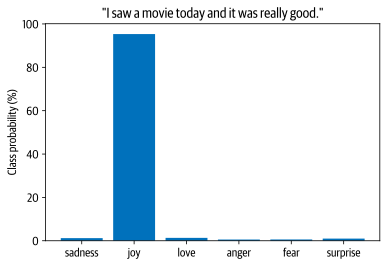

In [ ]:
preds_df = pd.DataFrame(preds[0])
plt.bar(labels, 100 * preds_df["score"], color='C0')
plt.title(f'"{custom_tweet}"')
plt.ylabel("Class probability (%)")
plt.show()

## Conclusion

Congratulations, you now know how to train a transformer model to classify the emotions in tweets! We have seen two complementary approaches based on features and fine-tuning, and investigated their strengths and weaknesses.

However, this is just the first step in building a real-world application with transformer models, and we have a lot more ground to cover. Here's a list of challenges you're likely to experience in your NLP journey:

My boss wants my model in production yesterday!::
In most applications, your model doesn't just sit somewhere gathering dust - you want to make sure it's serving predictions! When a model is pushed to the Hub, an inference endpoint is automatically created that can be called with HTTP requests. We recommend checking out the [documentation](https://api-inference.huggingface.co/docs/python/html/index.html) of the Inference API if you want to learn more.

My users want faster predictions!::
We've already seen one approach to this problem: using DistilBERT. In <<chapter_compression>> we'll dive into knowledge distillation (the process by which DistilBERT was created), along with other tricks to speed up your transformer models.


Can your model also do X?::
As we've alluded to in this chapter, transformers are extremely versatile. In the rest of the book we will be exploring a range of tasks, like question answering and named entity recognition, all using the same basic architecture.

None of my texts are in English!::
It turns out that transformers also come in a multilingual variety, and we'll use them in <<chapter_ner>> to tackle several languages at once.

I don't have any labels!::
If there is very little labeled data available, fine-tuning may not be an option. In <<chapter_fewlabels>>, we'll explore some techniques to deal with this situation.

Now that we've seen what's involved in training and sharing a transformer, in the next chapter we'll explore implementing our very own transformer model from scratch.

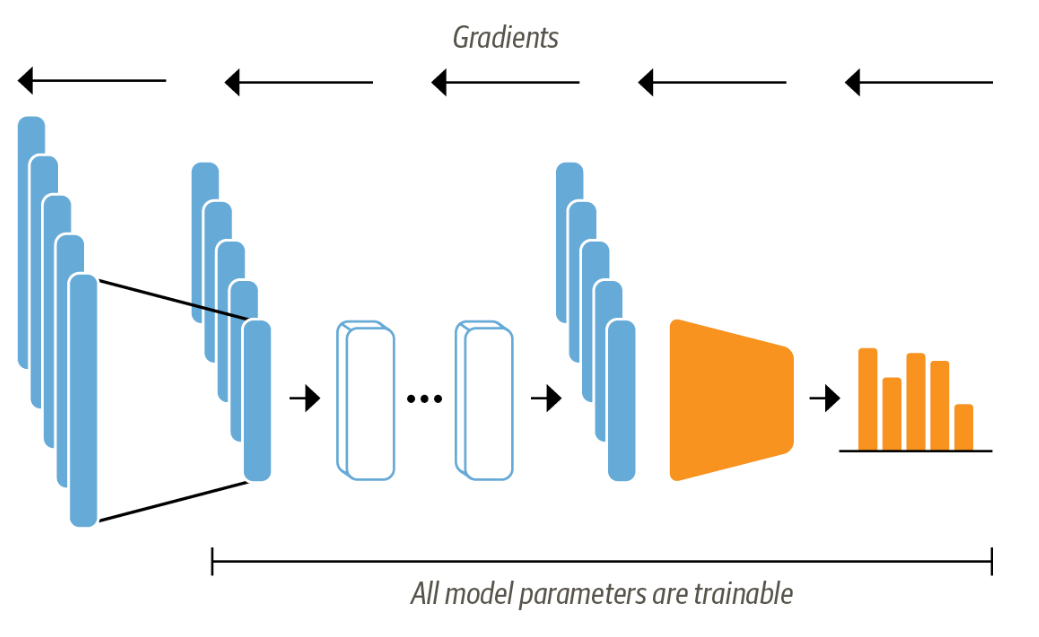

$\rule{800pt}{20pt}$